#Day21. 머신러닝기초

---



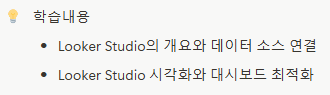

## Day20 수업 이어서 진행



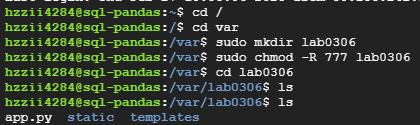  
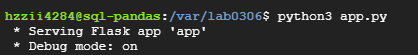

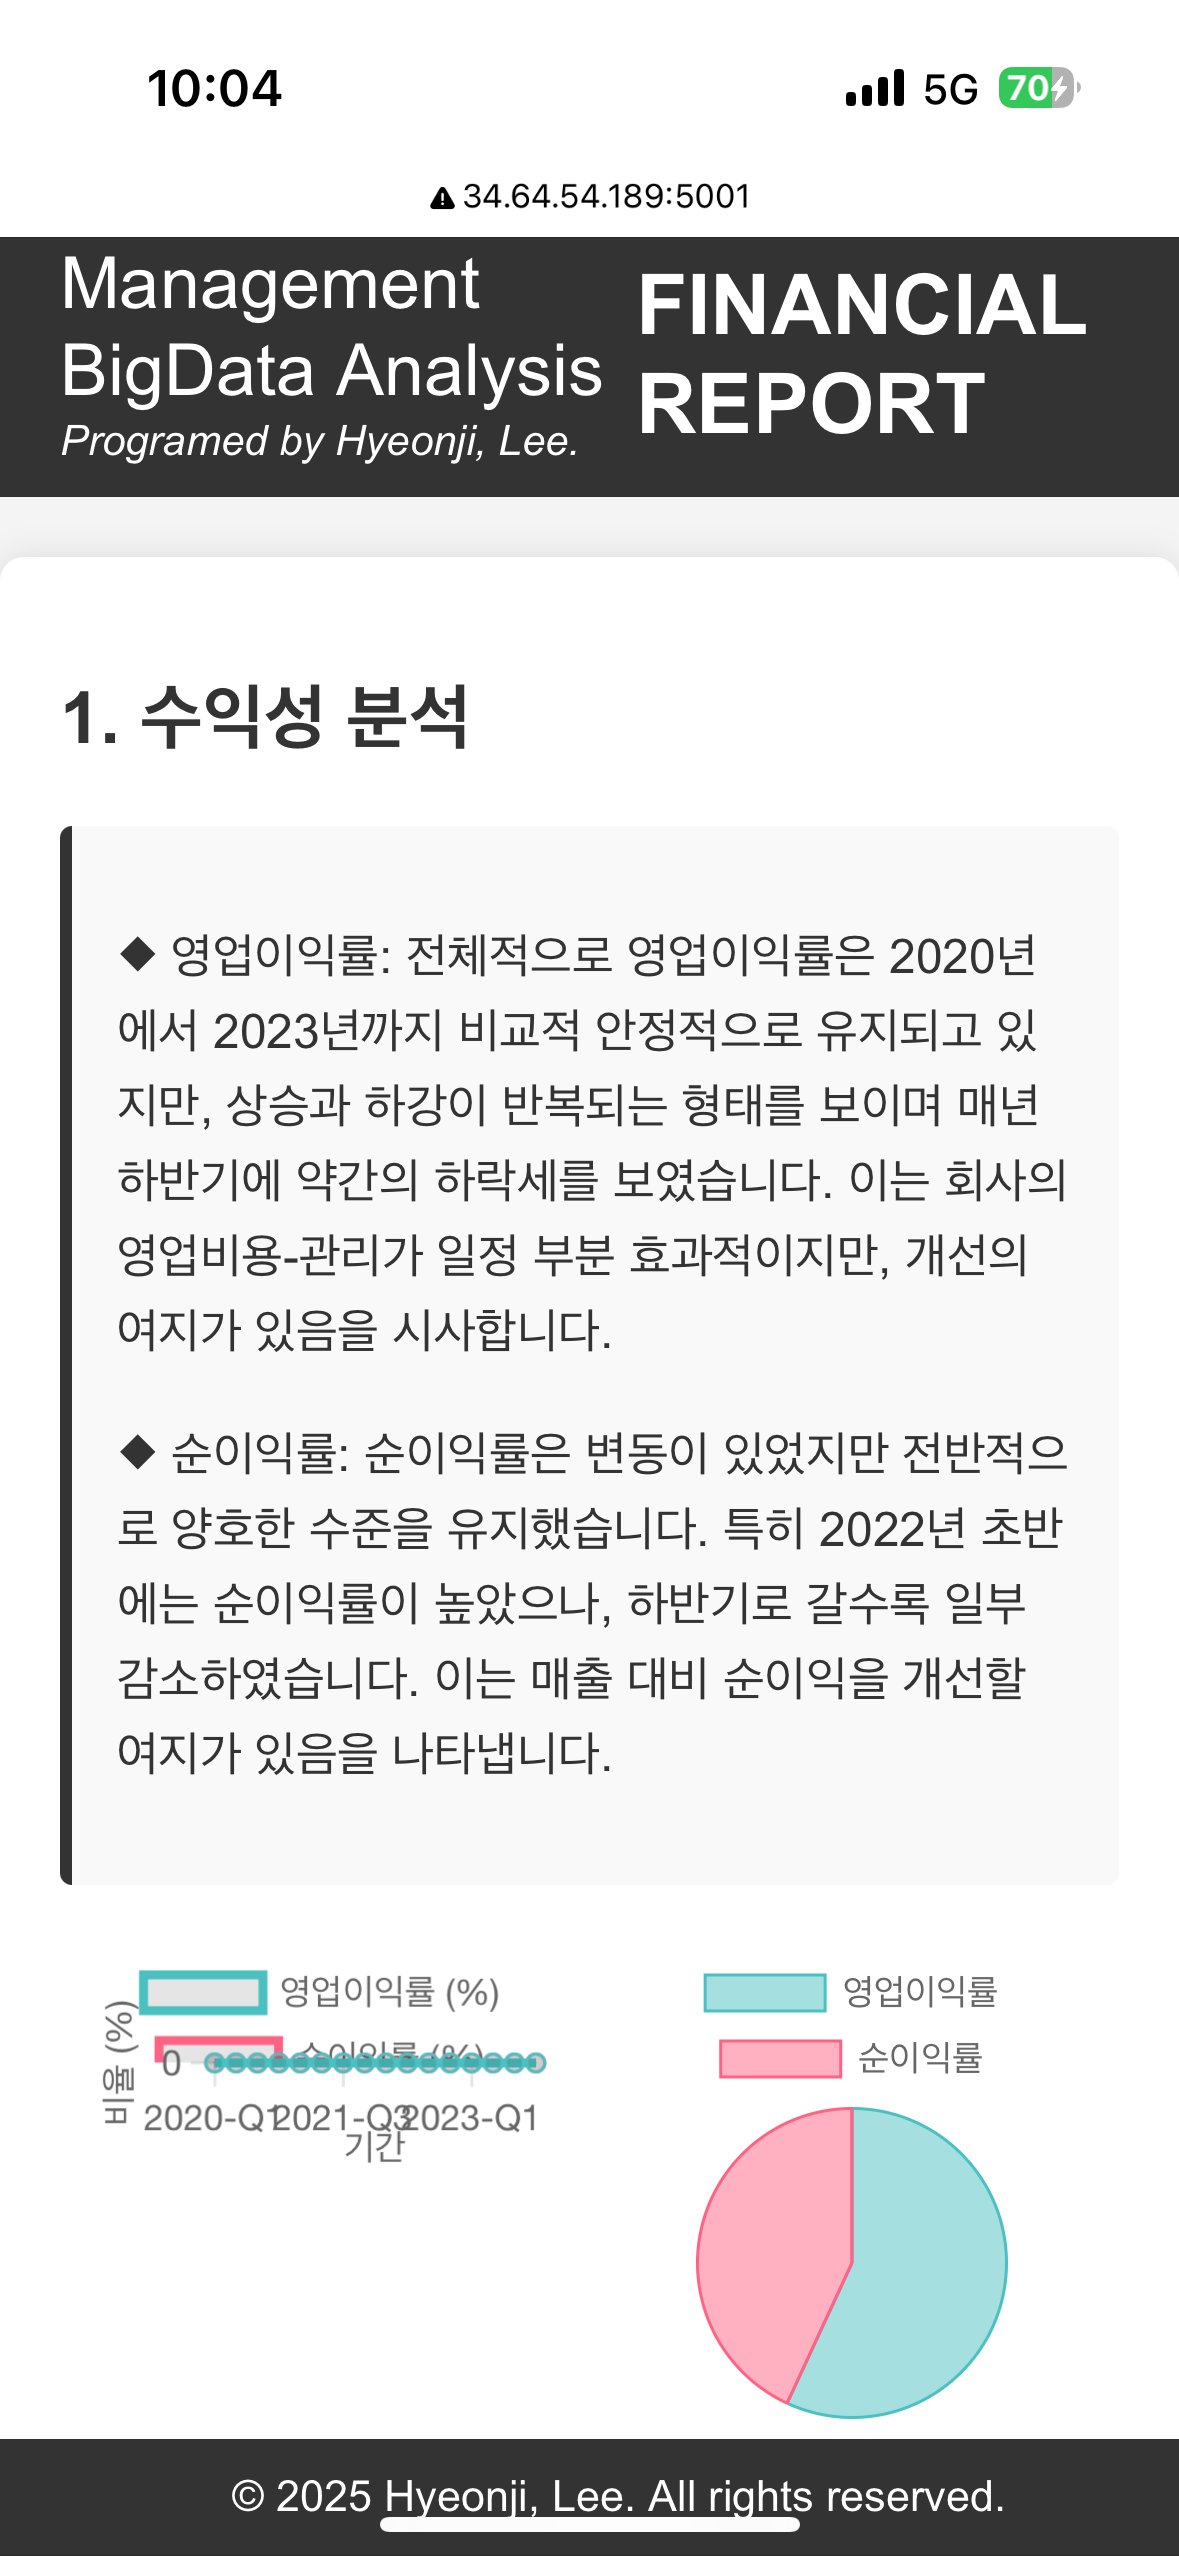  
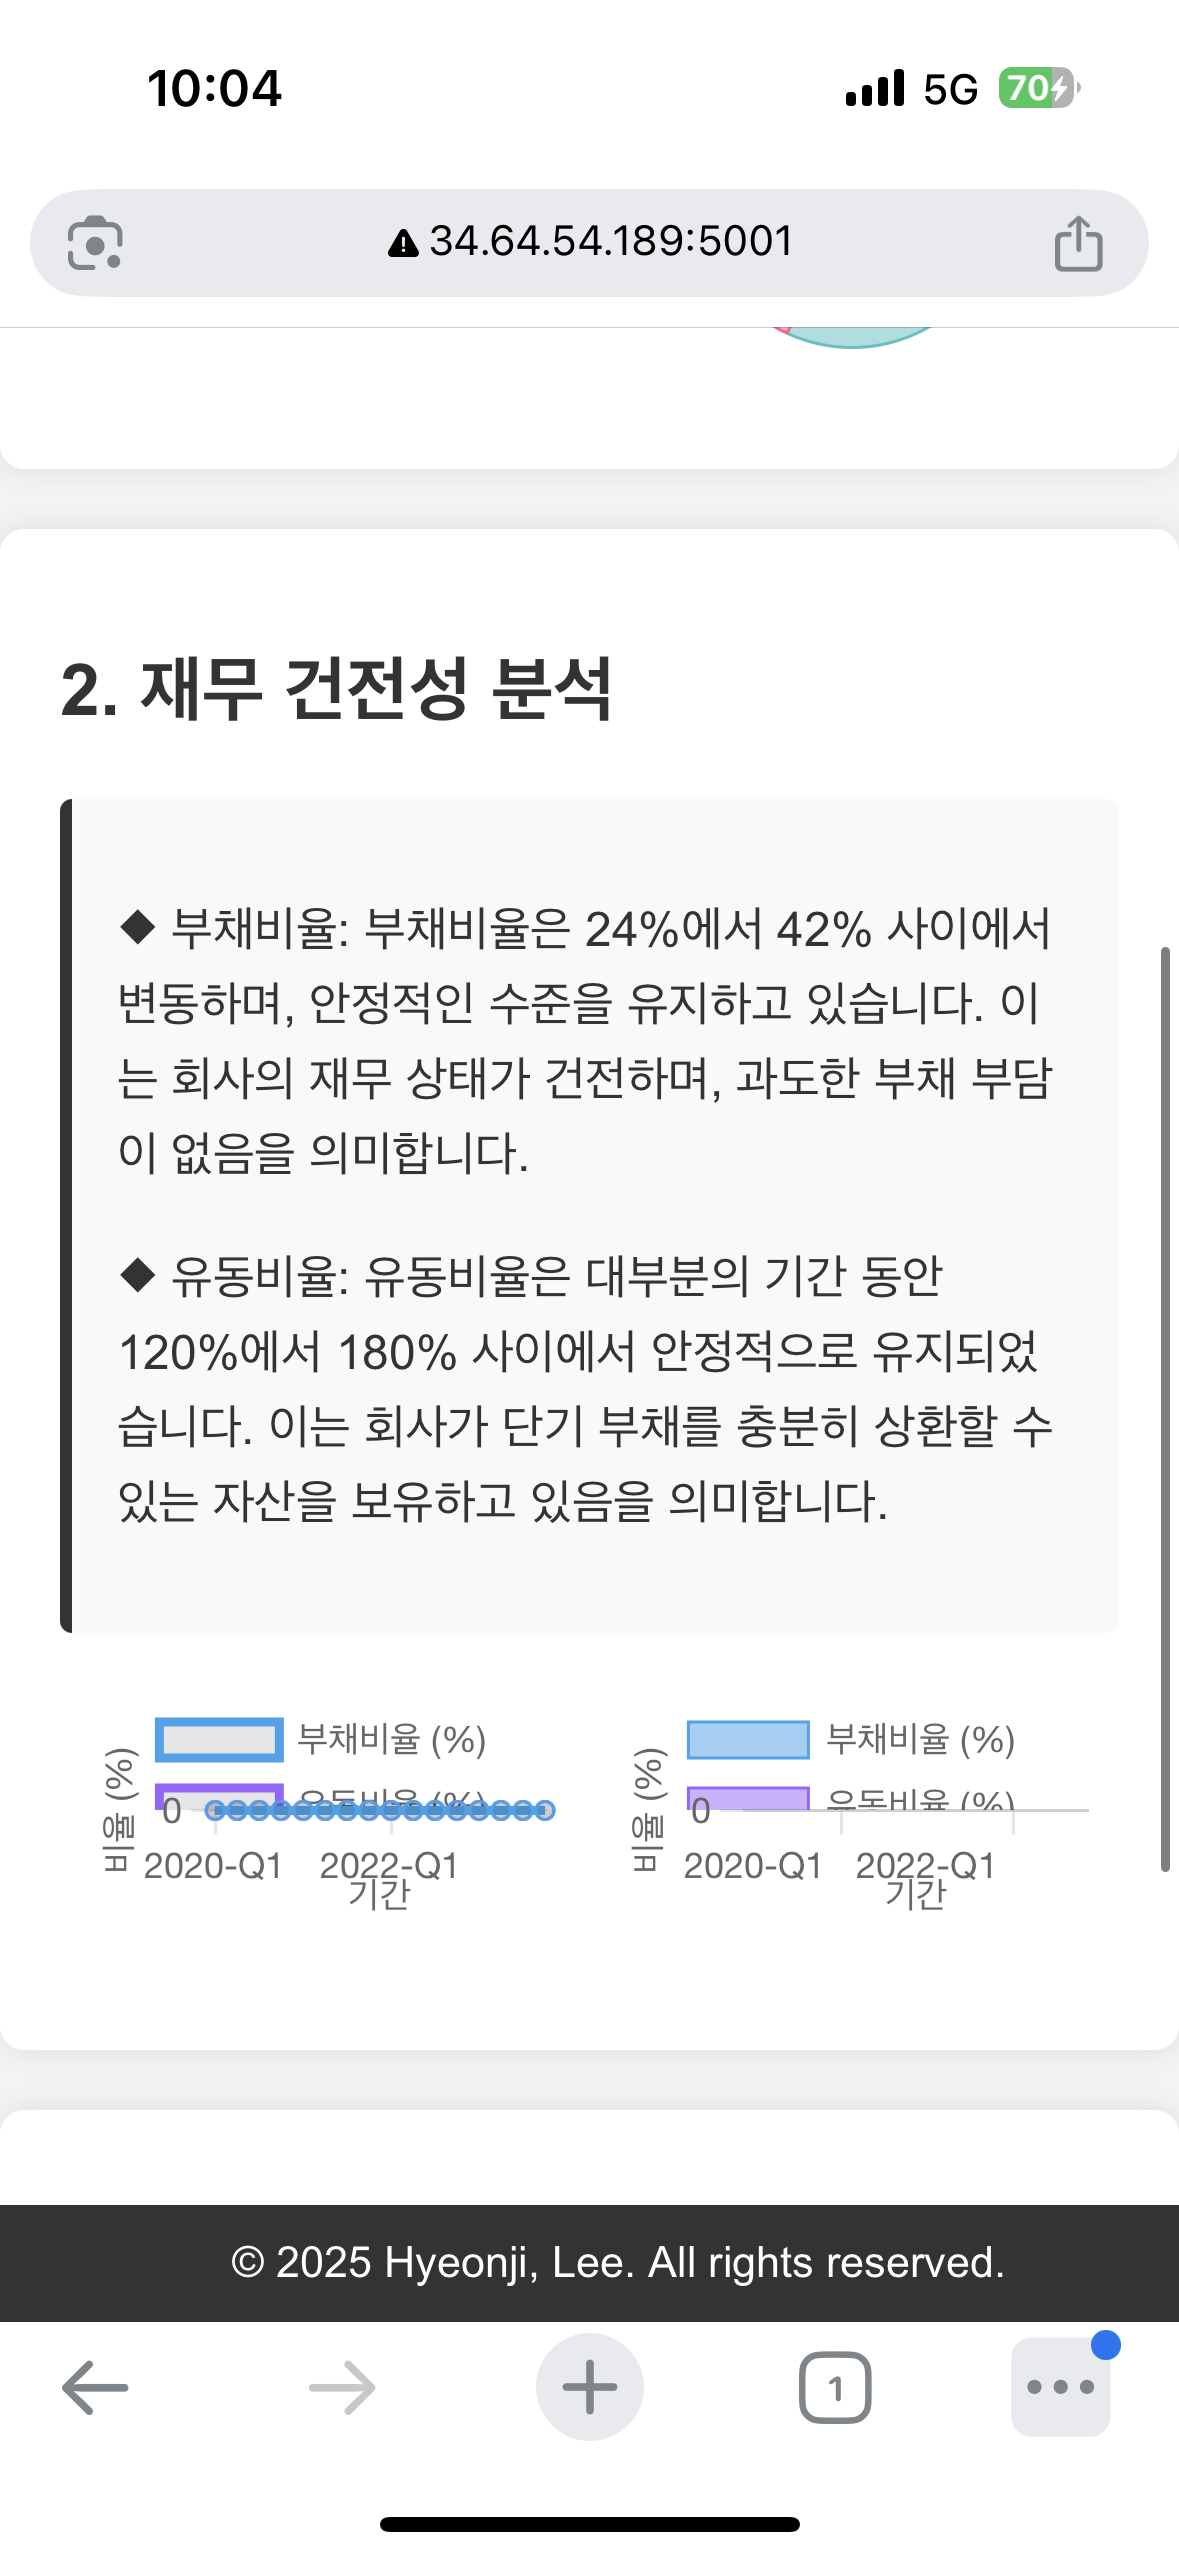   
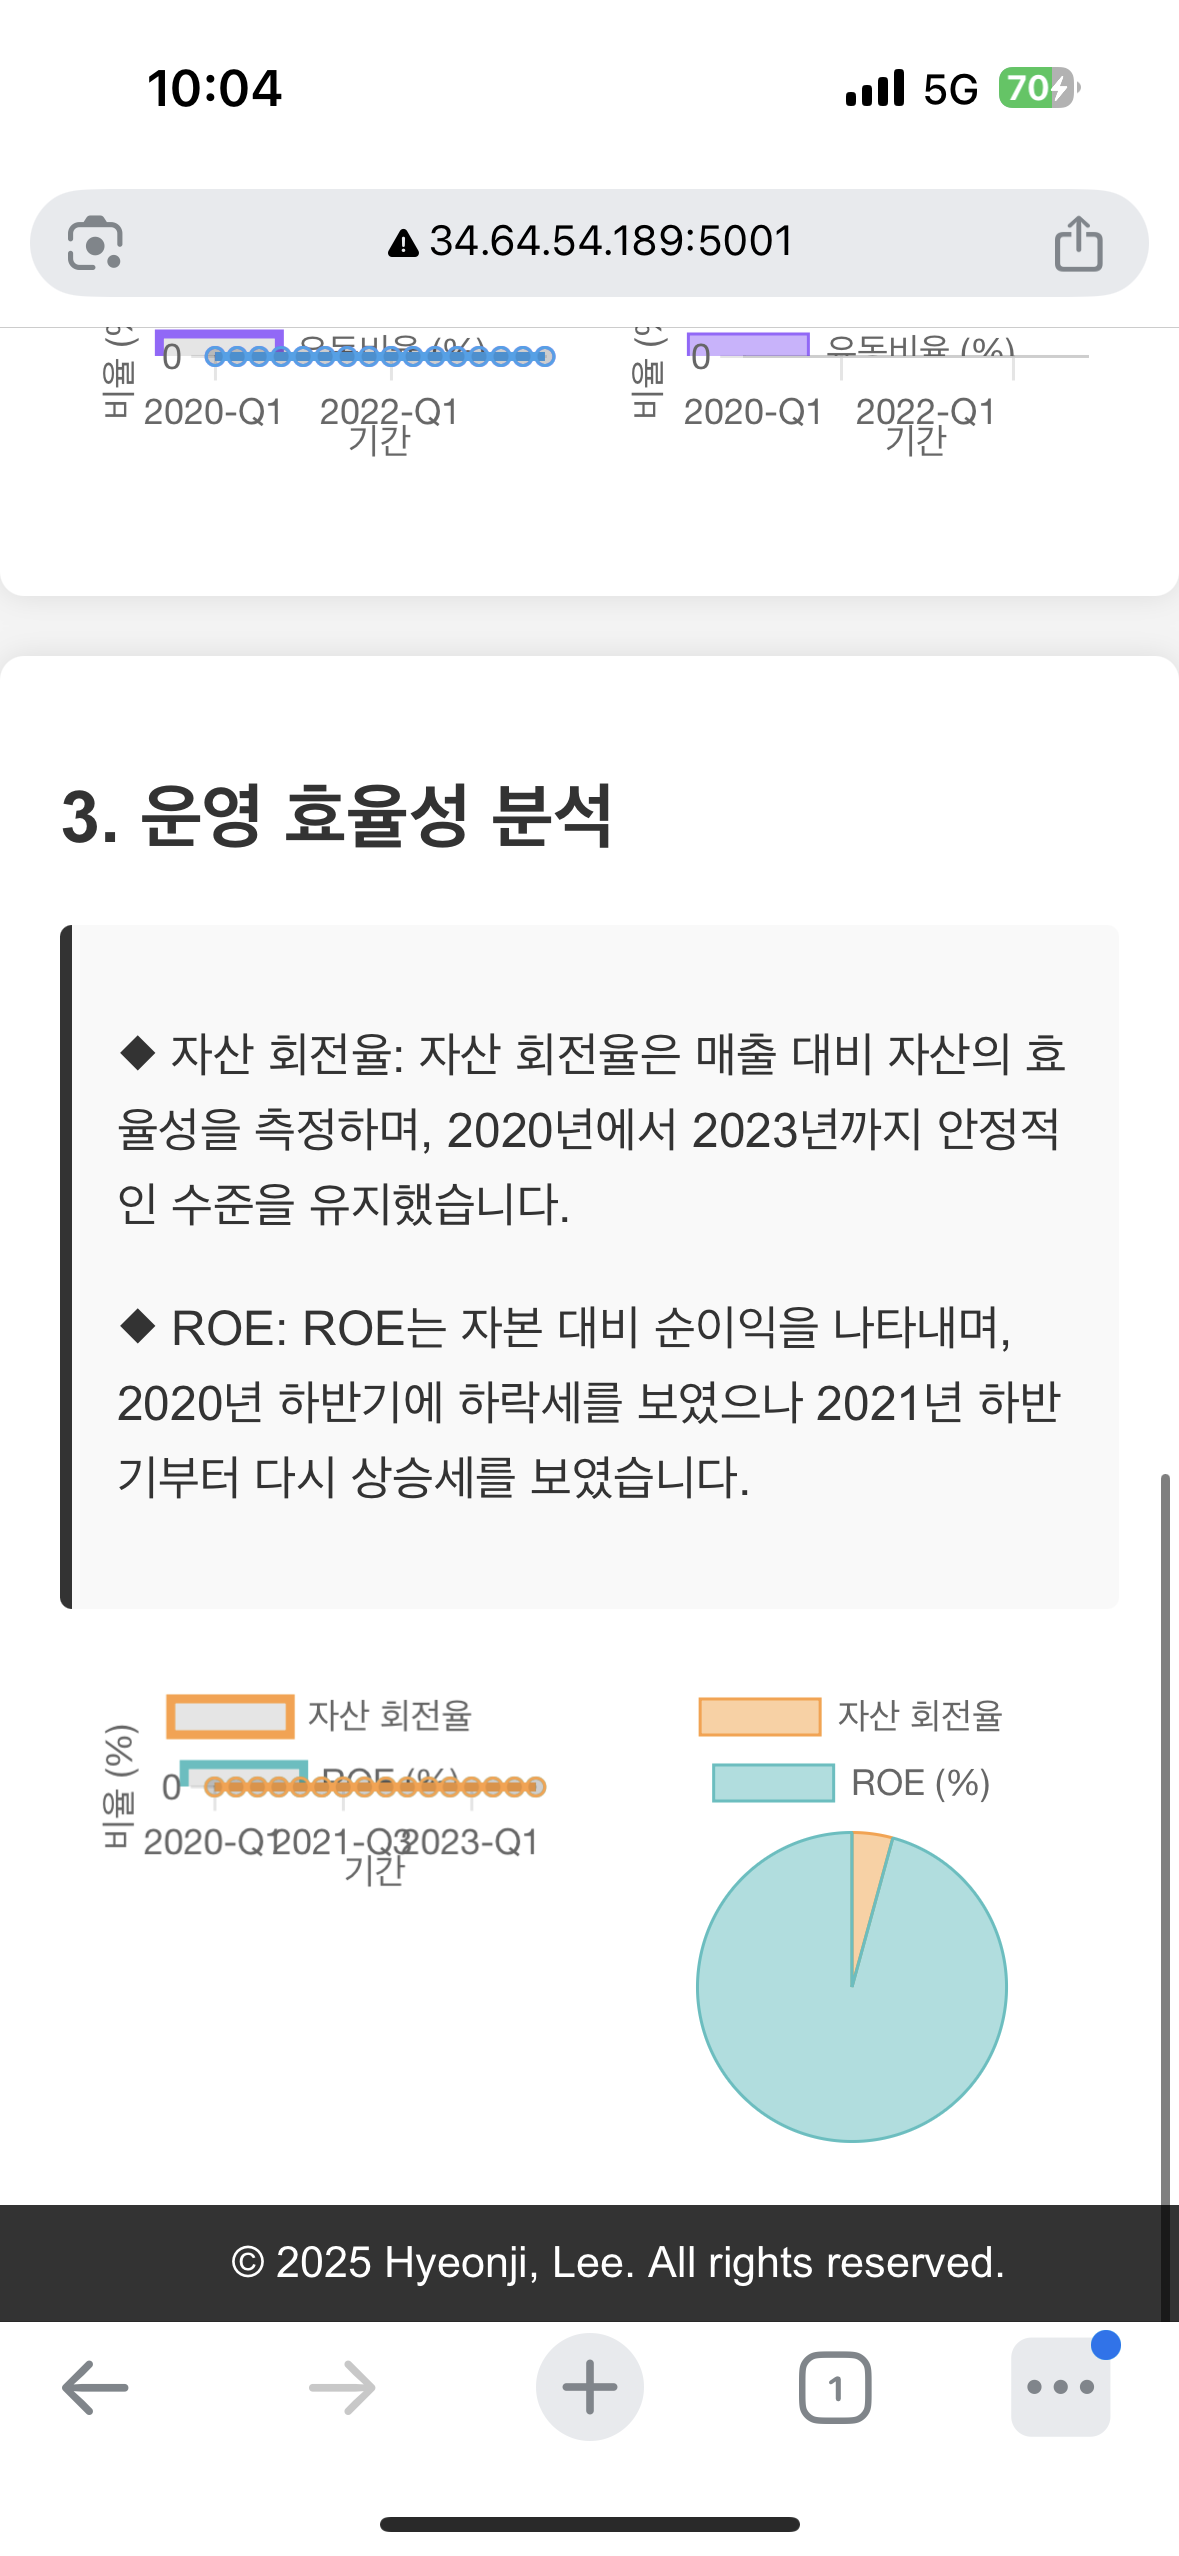



---

##**Looker Studio**

Google에서 제공하는 데이터 시각화 및 보고서 제작 도구로, 데이터를 이해하기 쉽게 대시보드 형태로 시각화할 수 있도록 지원  
비즈니스 인텔리전스(BI) 도구로 활용되며, Google의 다양한 서비스 및 타사 데이터 소스와 연동이 가능해 데이터를 효과적으로 분석하고 공유할 수 있음

### **주요 특징**

1. **다양한 데이터 소스 연결**
    - Google Analytics, Google Ads, BigQuery, Google Sheets 등 Google 제품과 원활히 통합됨
    - MySQL, PostgreSQL 같은 데이터베이스, CSV 파일, 또는 타사 API를 통해 외부 데이터를 연결할 수 있음
2. **사용자 친화적 인터페이스**
    - 코딩 지식 없이도 쉽게 대시보드와 보고서를 생성할 수 있는 드래그 앤 드롭 방식의 UI 제공
    - 원하는 데이터 필드를 추가하거나 필터링, 정렬을 간단히 설정할 수 있음
3. **실시간 데이터 업데이트**
    - 연결된 데이터 소스에서 실시간으로 데이터를 가져와 보고서를 동적으로 업데이트
4. **맞춤형 시각화**
    - 다양한 차트 유형(라인 차트, 바 차트, 파이 차트 등)과 지도 시각화 지원
    - 사용자가 원하는 디자인으로 대시보드를 커스터마이징할 수 있음
5. **협업 및 공유**
    - Google Drive와 연동되어 대시보드를 팀원들과 공유하거나 협업할 수 있음
    - 실시간으로 업데이트된 데이터를 기반으로 공동 작업 가능
6. **무료로 제공**
    - Looker Studio는 기본적으로 무료로 제공되며, 일부 고급 기능은 유료 서비스(예: Looker Studio Pro)에서 제공

### **사용 사례**

- **마케팅 데이터 분석**: Google Ads와 Google Analytics 데이터를 연결해 캠페인 성과를 시각화
- **비즈니스 리포트 생성**: 판매 데이터를 실시간으로 시각화해 의사결정 지원
- **교육 및 학습 데이터 분석**: 학생 성적 데이터를 분석하고 학습 경향을 시각적으로 표현

### **장점**

- 무료로 제공되며 사용이 간단
- 다양한 데이터 소스와 통합 가능
- 실시간으로 데이터를 업데이트하여 최신 데이터를 반영

### **단점**

- 복잡한 데이터 분석을 위한 고급 기능은 제한적
- 일부 데이터 소스 연결 시 추가 설정이 필요

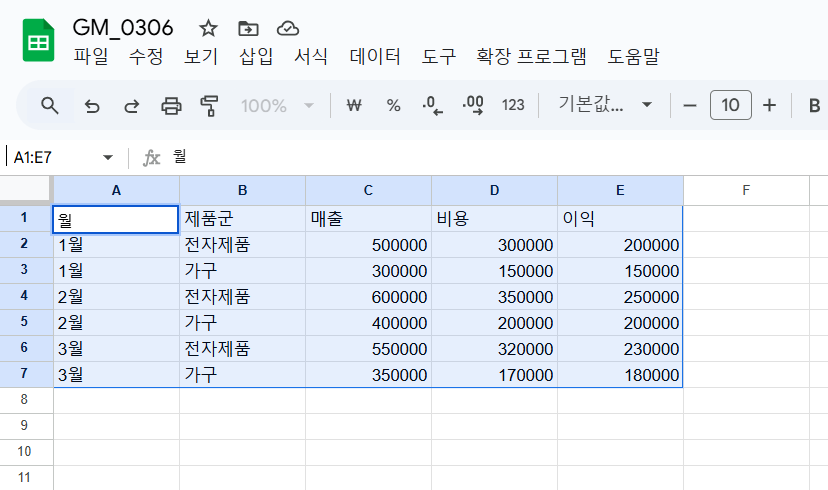

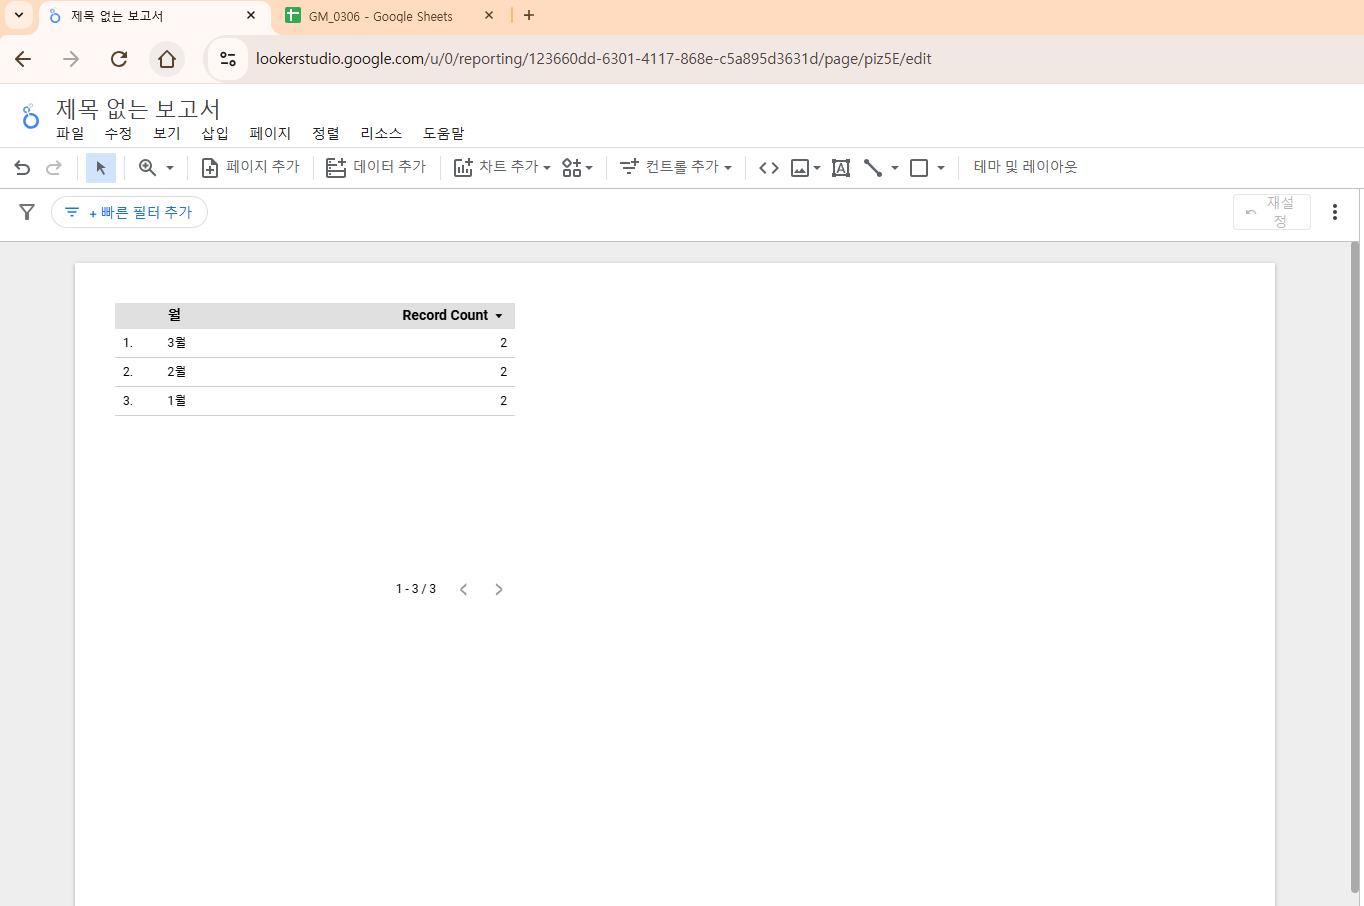

**바 차트 추가**

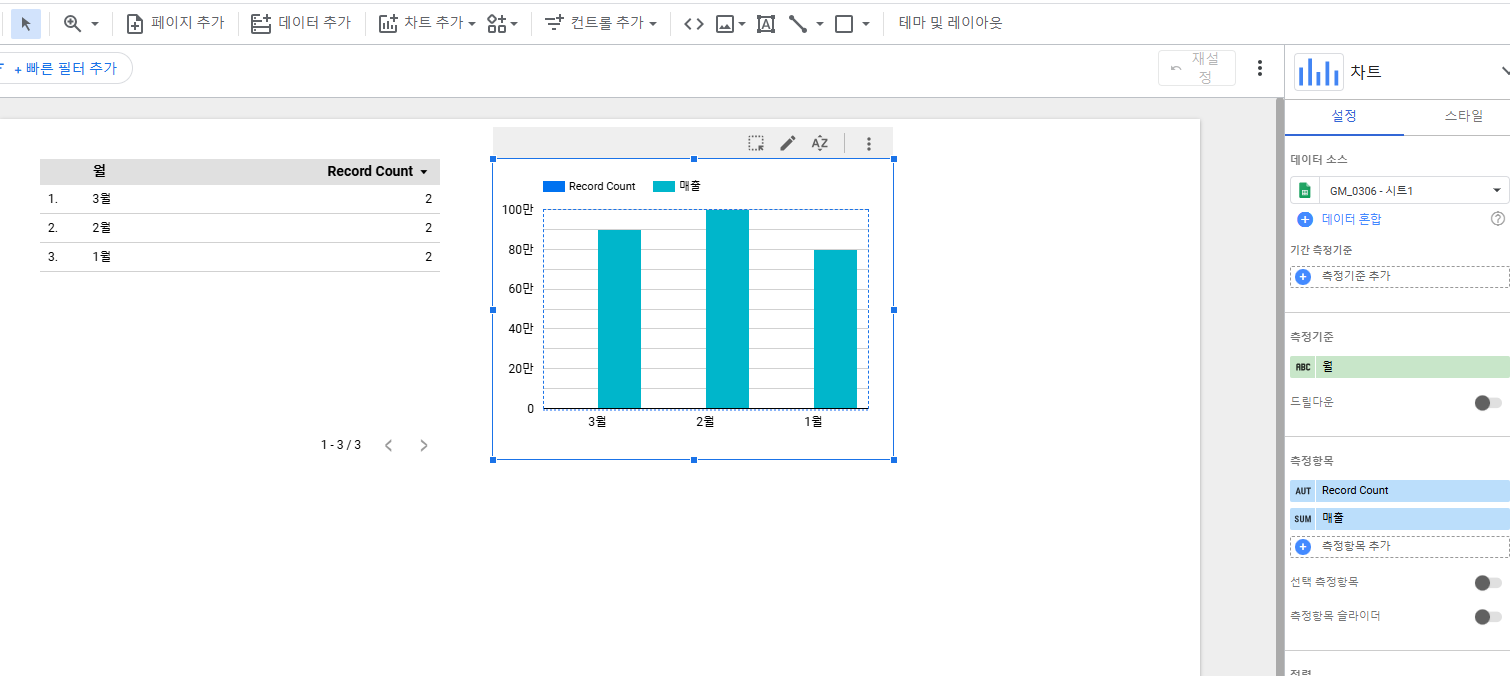

**파이 차트 추가**

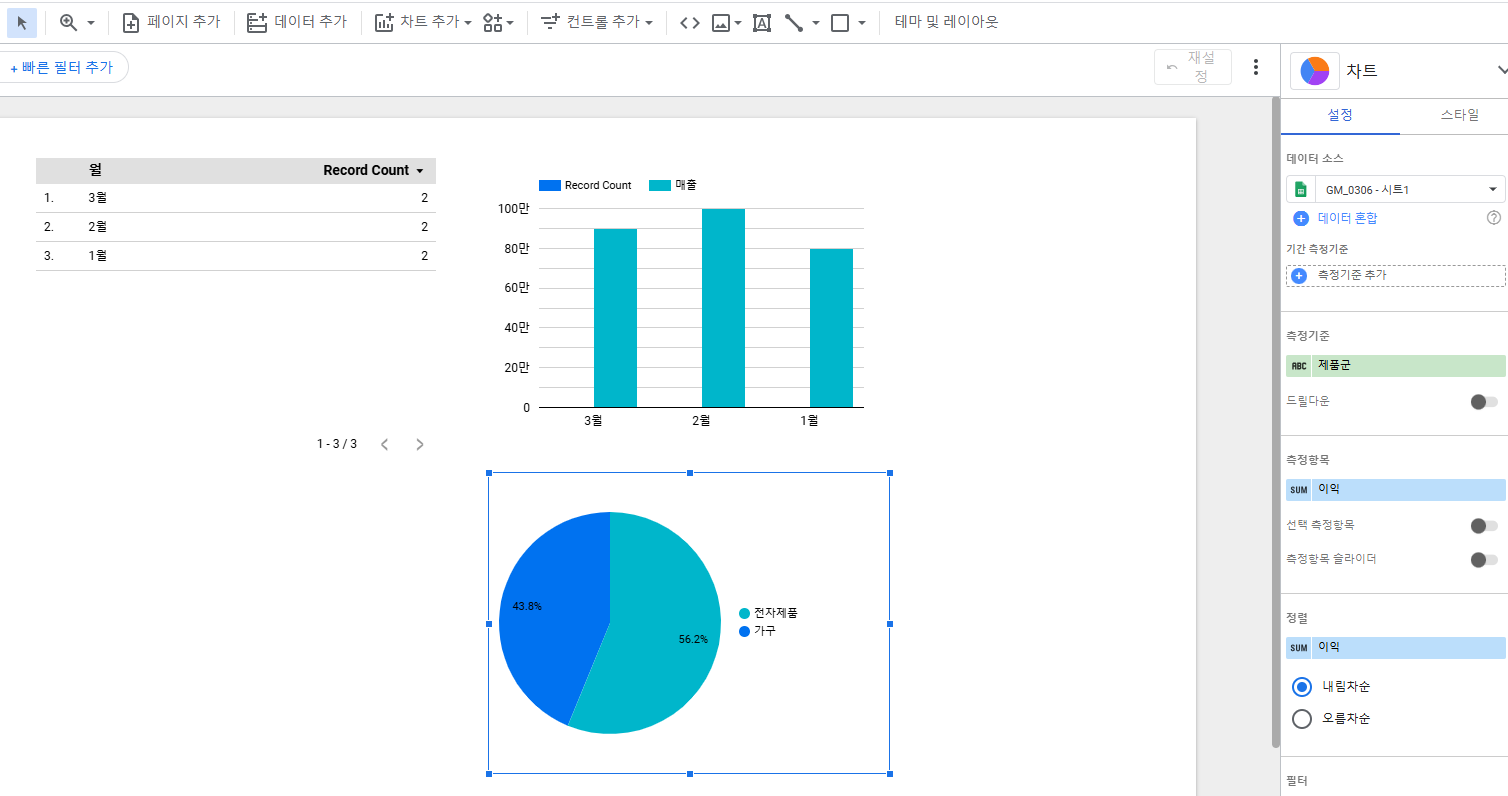

**테이블 추가**

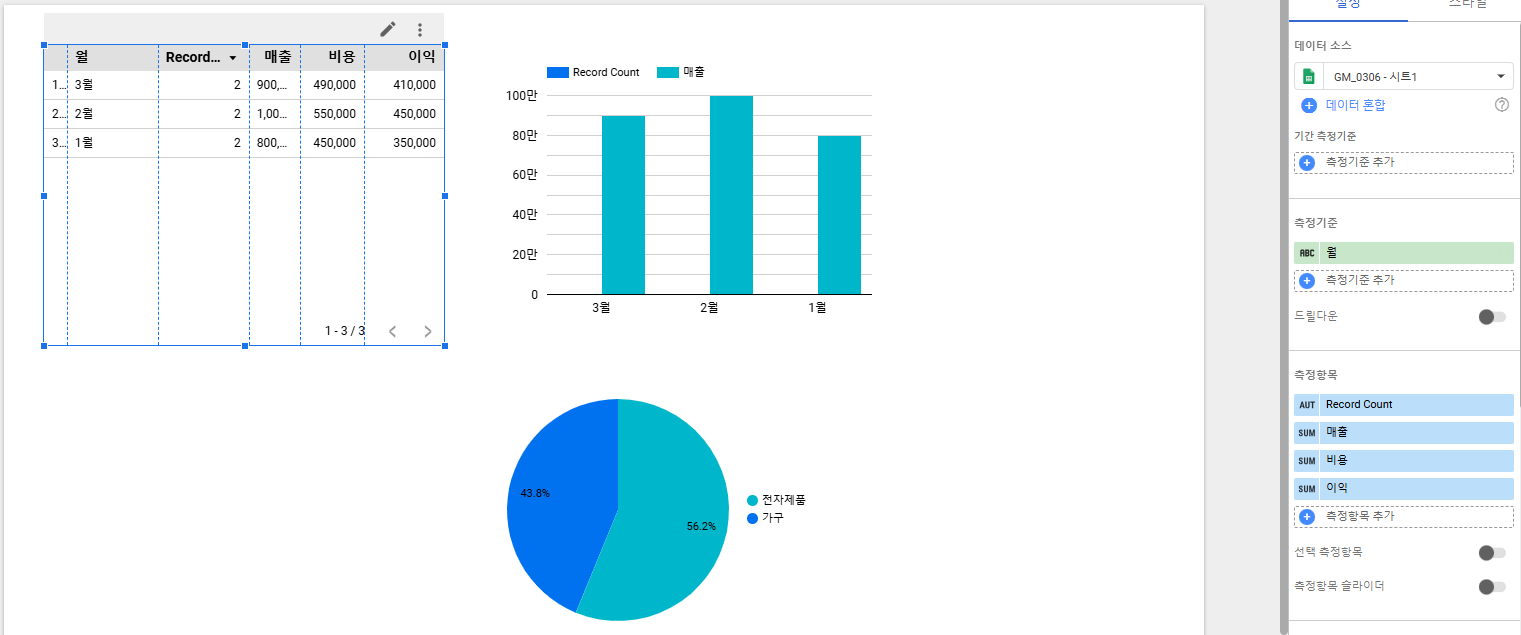

**필터 및 날짜 범위 추가**

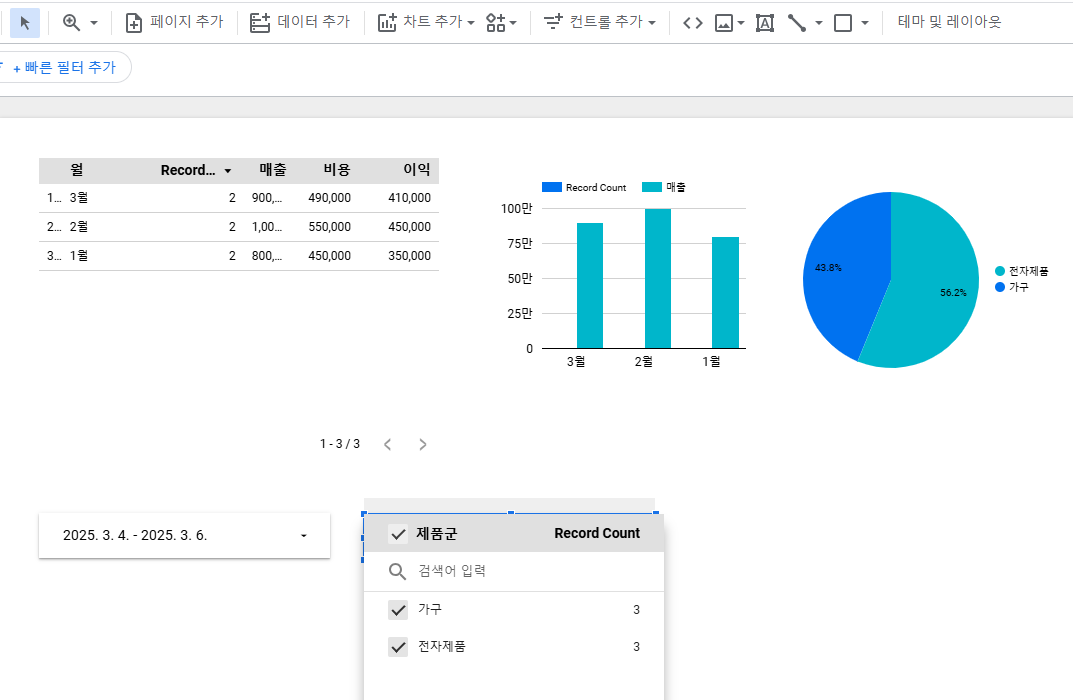



---



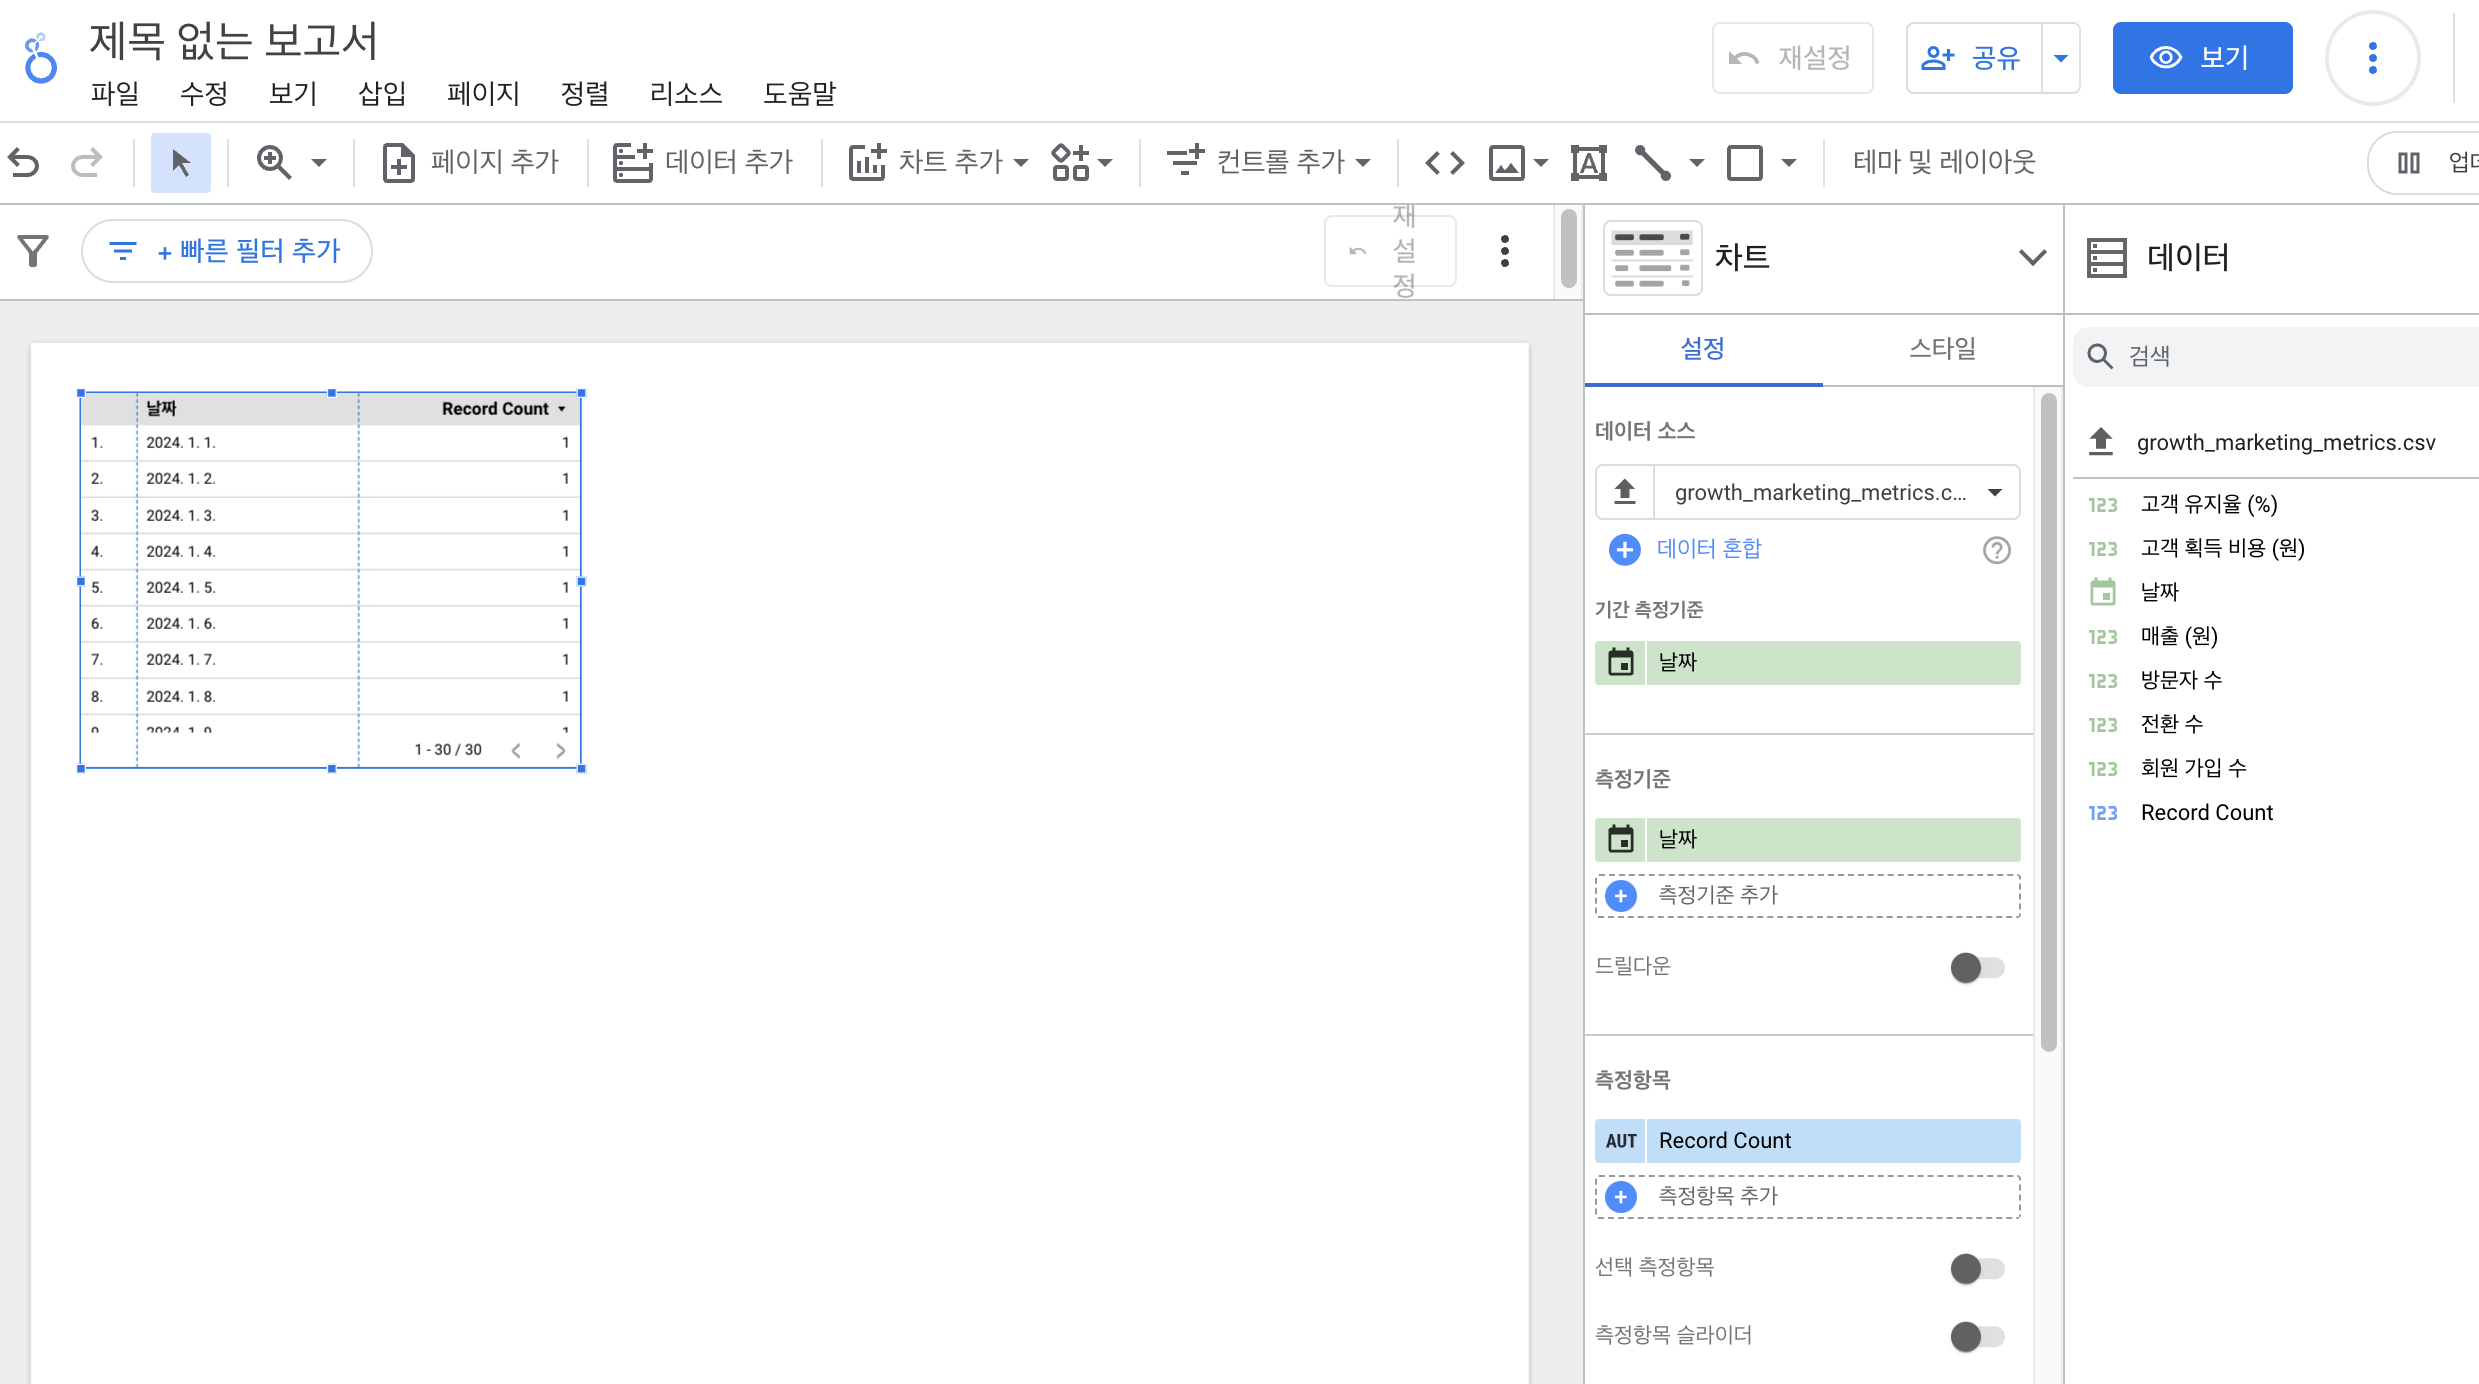

**날짜별 방문자 수 추이 (시계열 차트)**

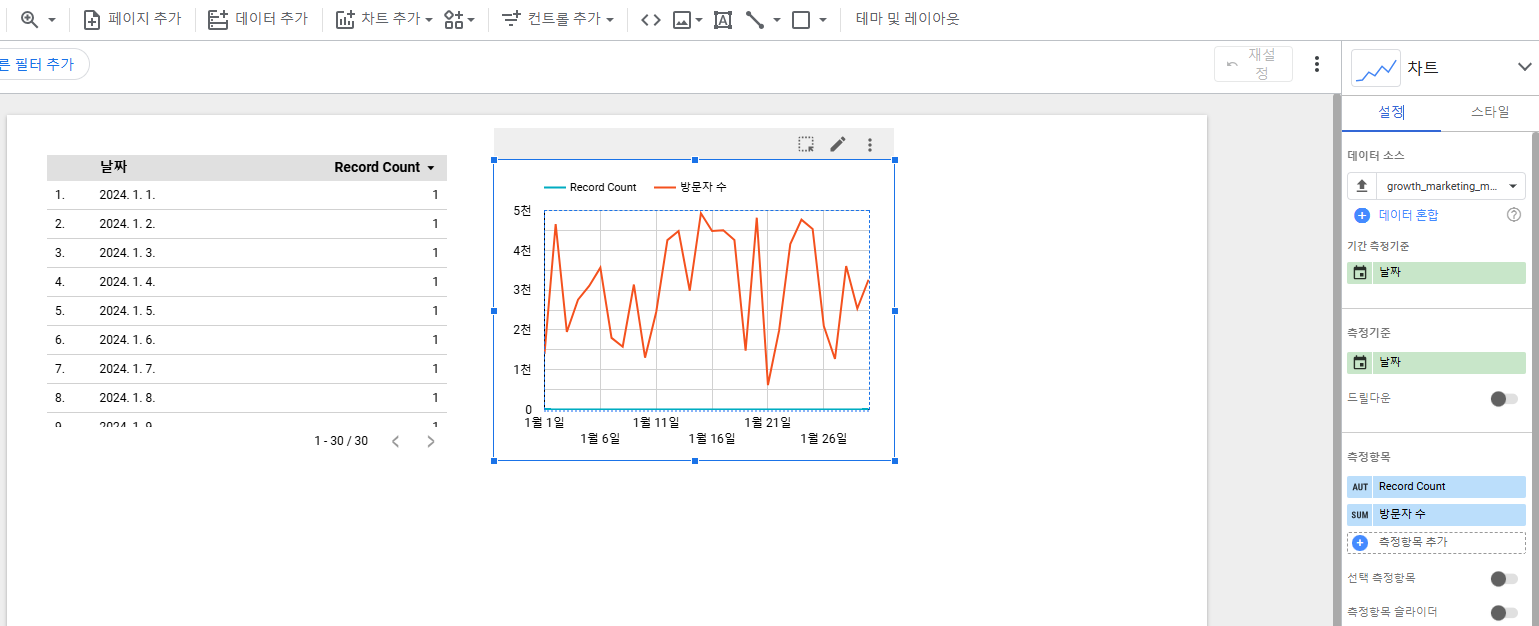

**회원 가입 수와 전환 수 비교 (막대 차트)**

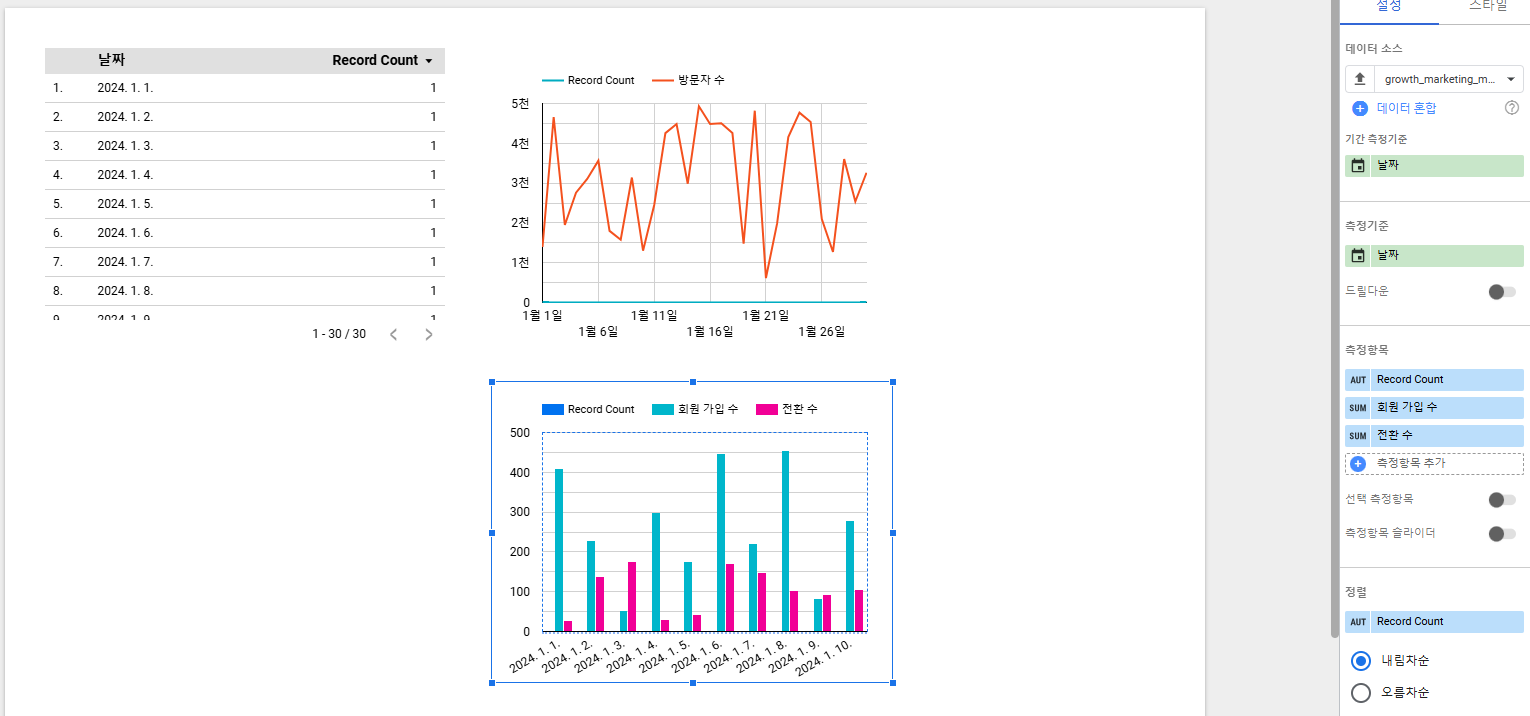

**매출 추이 분석 (영역 차트)**

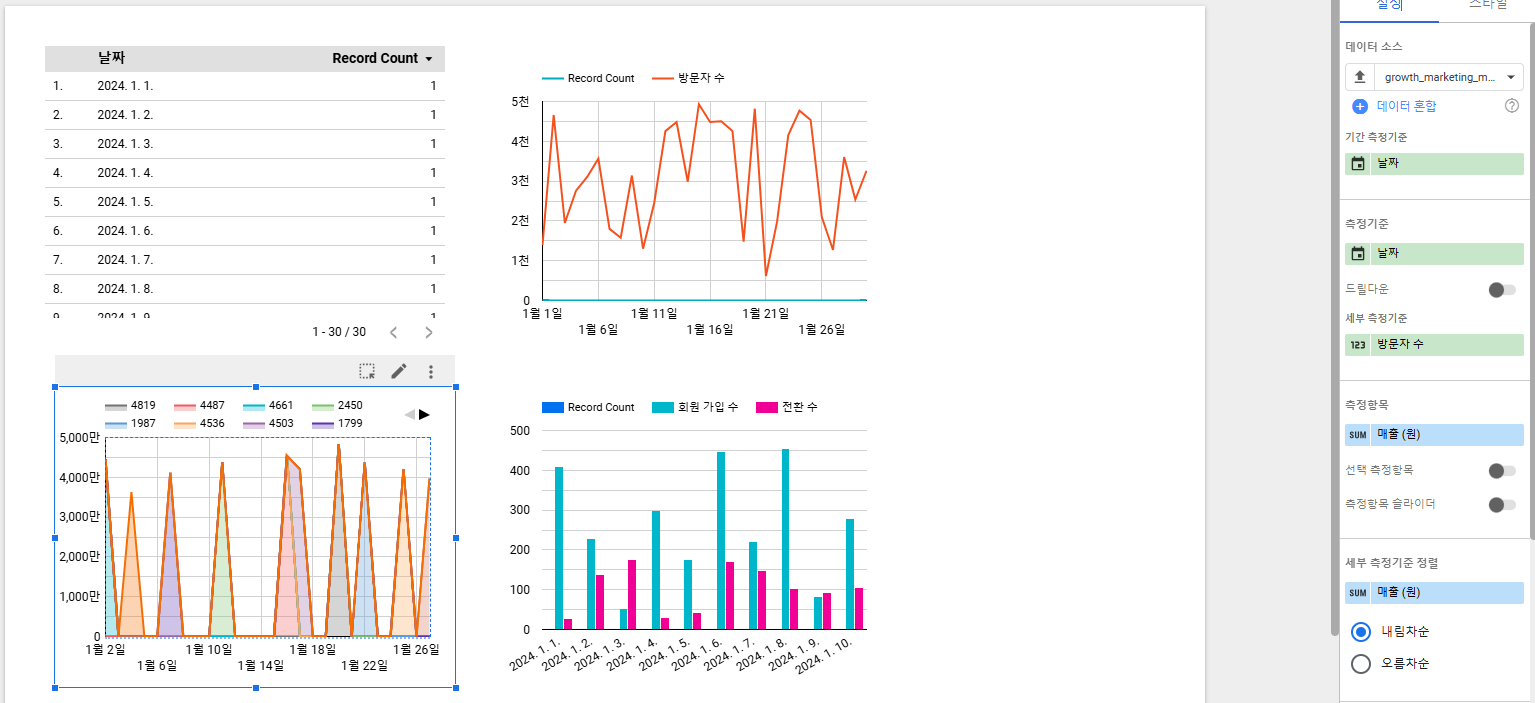

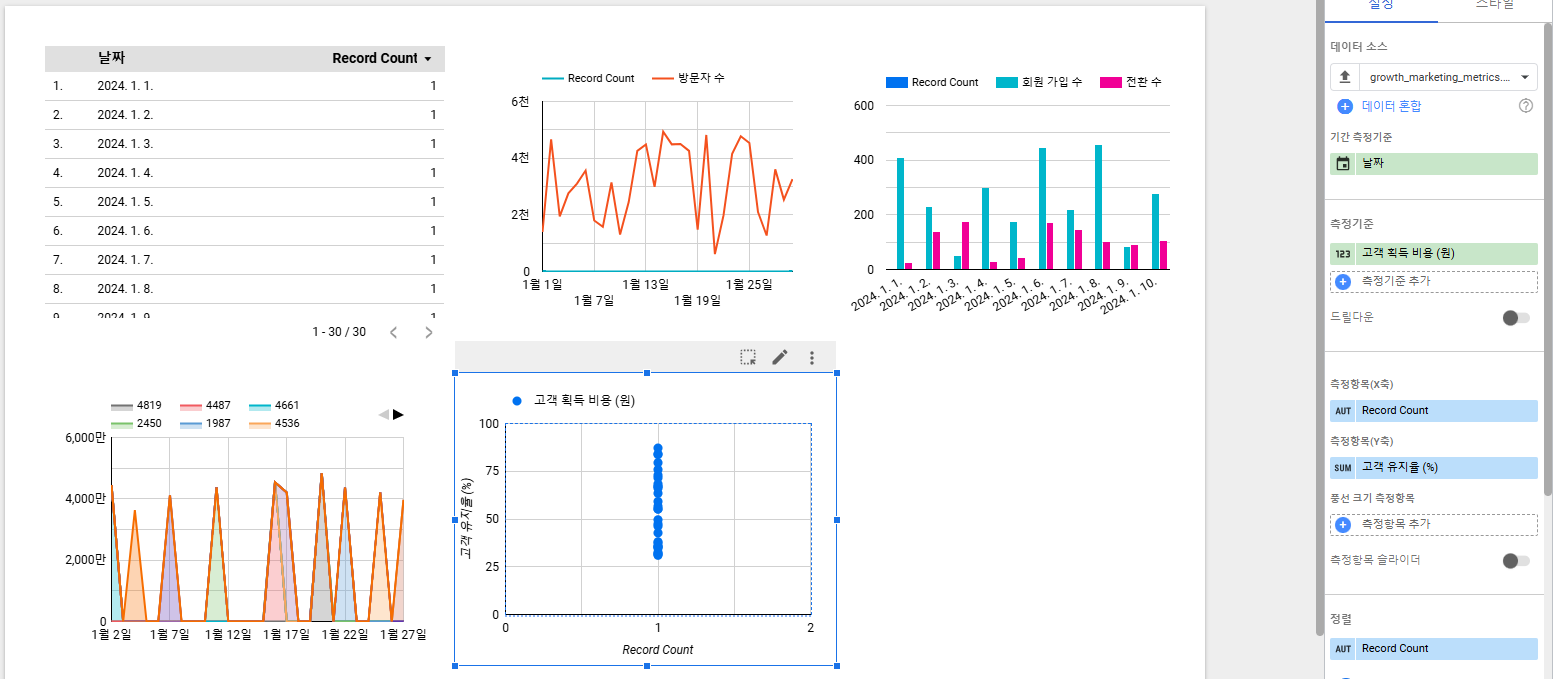

**주요 성과 지표 (스코어카드)**

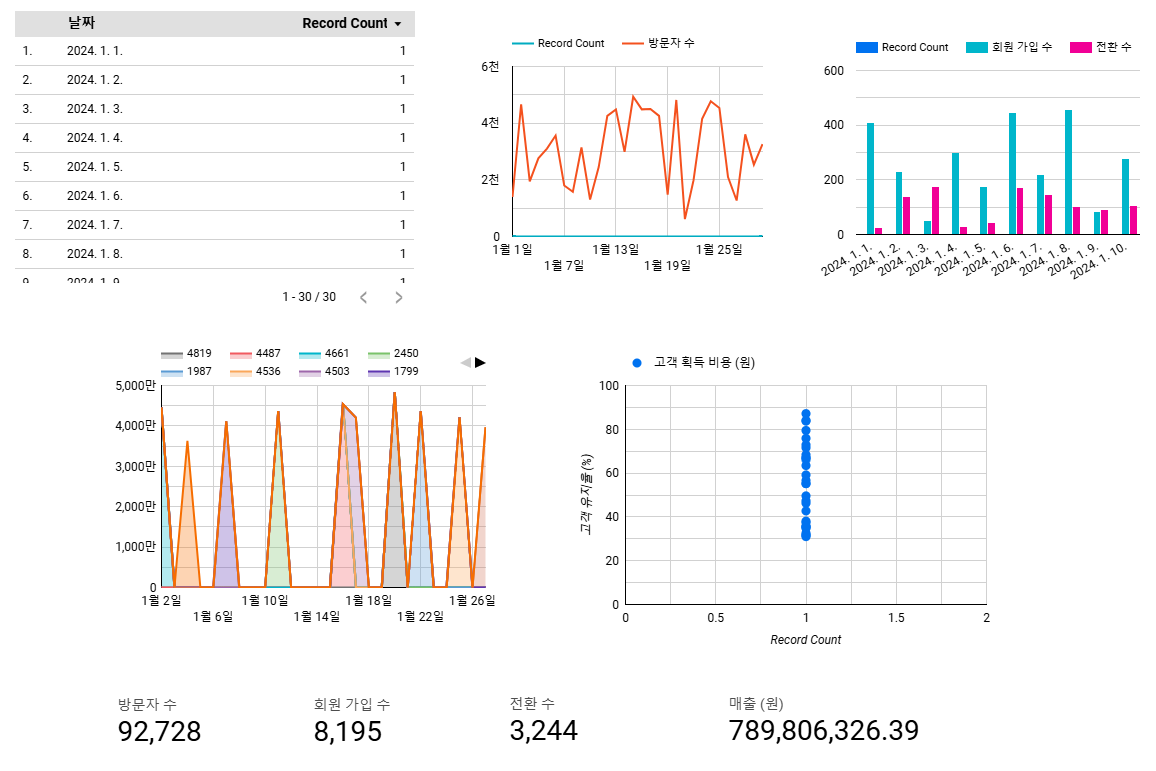

공유 링크 https://lookerstudio.google.com/s/kL2fqKZGOiI



---

##**Looker studio MariaDB 연동**

looker 인스턴스 생성

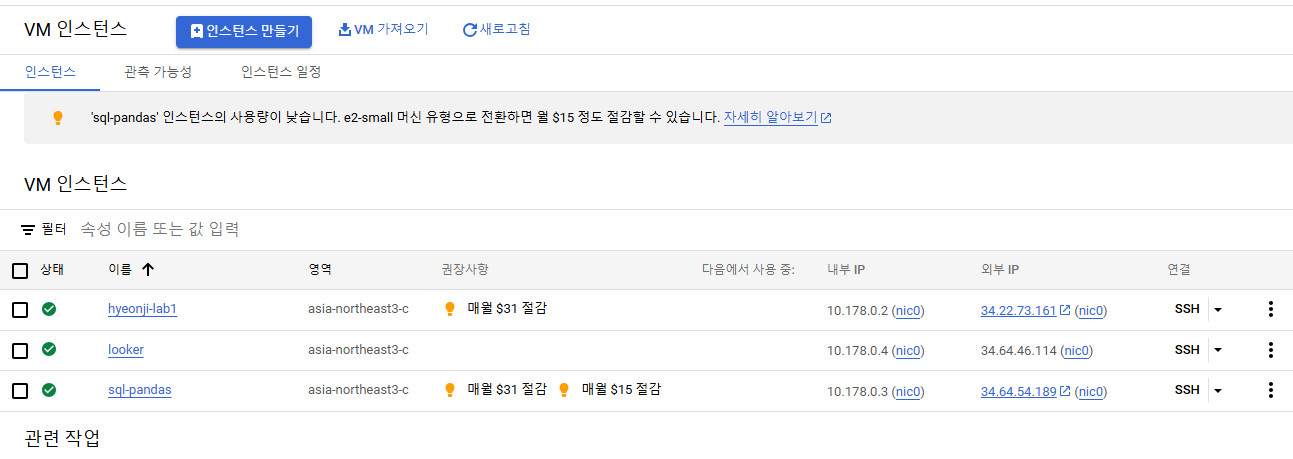

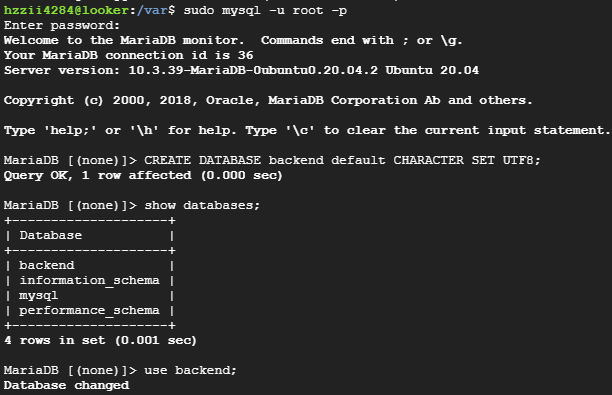  
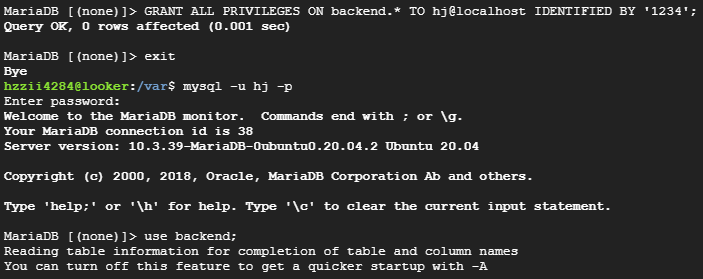

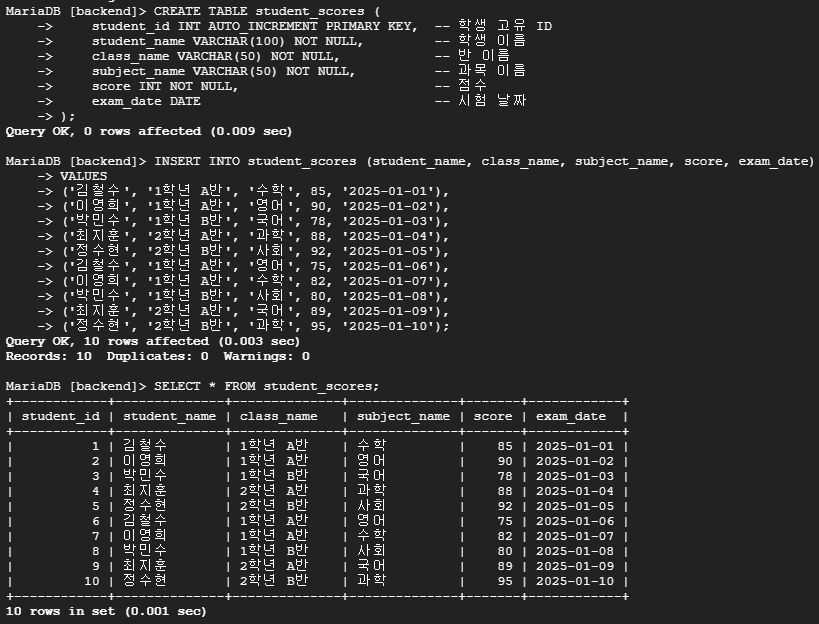



---


### **MariaDB의 원격 접속 설정**

1. **MariaDB 설정 파일 수정**
    - `sudo nano /etc/mysql/mariadb.conf.d/50-server.cnf` 파일을 열어 아래 내용을 확인/수정합니다:
        
        ```
        bind-address = 0.0.0.0
        ```
        
    - 기본값은 `127.0.0.1`으로 되어 있어 외부에서 접속할 수 없습니다. 이를 `0.0.0.0`으로 변경합니다.

2. **DNS 확인 비활성화 설정**
    - MariaDB 설정 파일(`/etc/mysql/mariadb.conf.d/50-server.cnf`)을 수정합니다.

```bash
	sudo nano /etc/mysql/mariadb.conf.d/50-server.cnf
```

- 파일에 아래 내용을 추가합니다(또는 주석 해제)

```
[mysqld]
skip-name-resolve
```

3. **MariaDB 사용자 원격 접속 권한 부여**

```jsx
GRANT ALL PRIVILEGES ON backend.* TO 'looker_user'@'%' IDENTIFIED BY '1234';
FLUSH PRIVILEGES;
```

4. **MariaDB 재시작**

```clojure
sudo systemctl restart mariadb
```

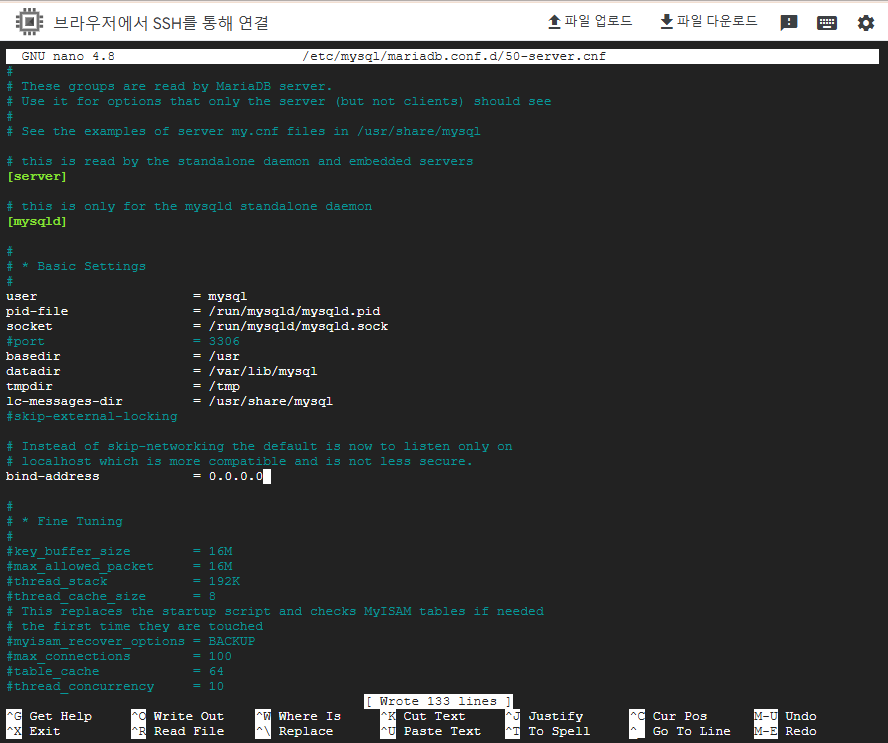

**ctrl+o** & enter: 저장

**ctrl+x** : 나가기

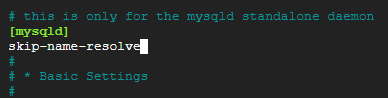

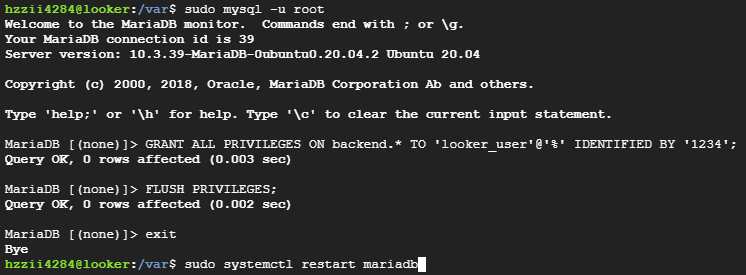

**Looker Studio에서 새 보고서 만들기**

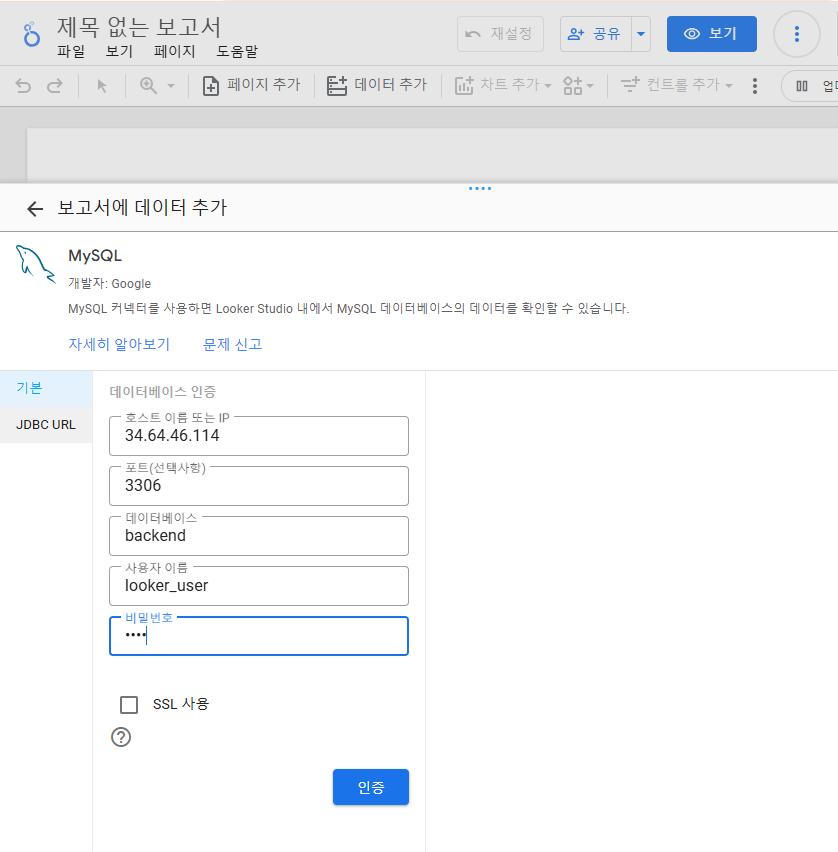

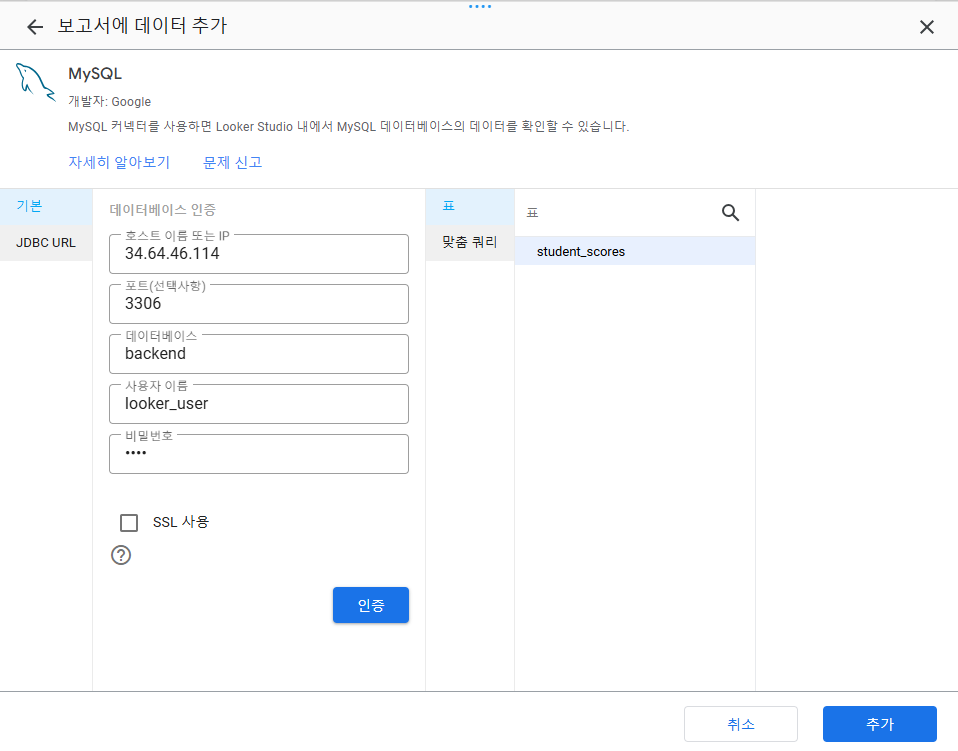

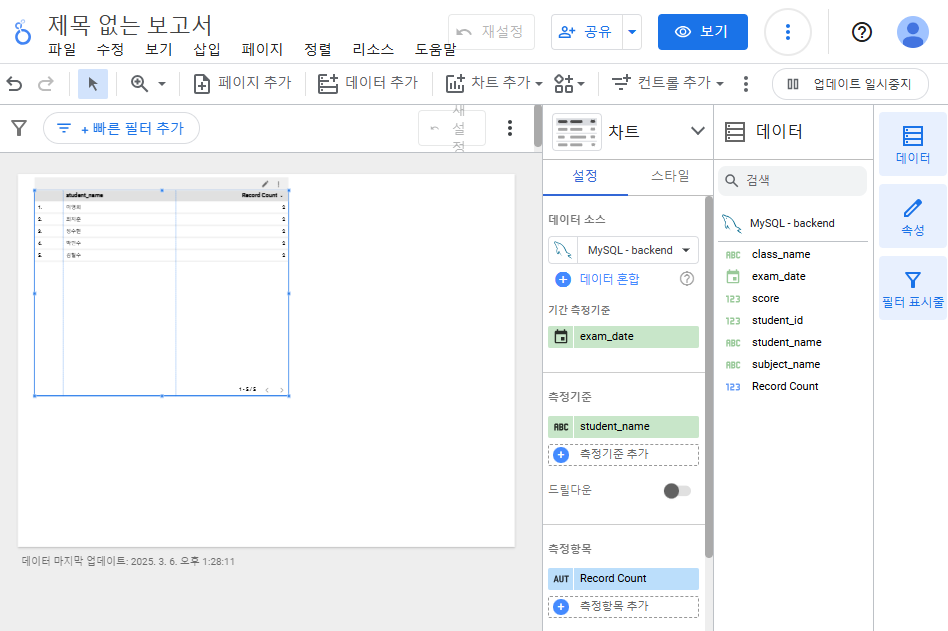

**차트 추가**

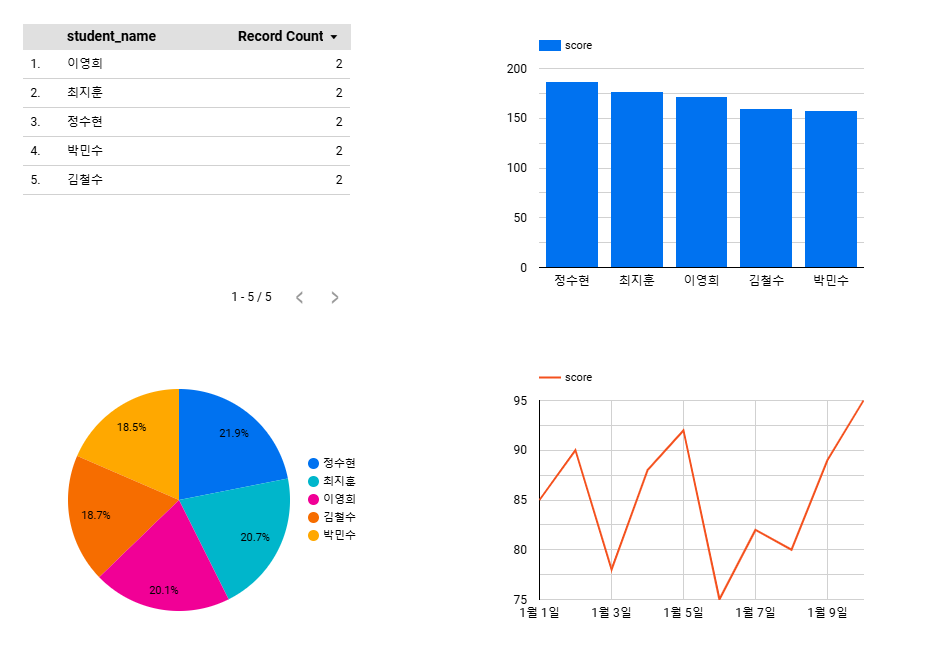



---

##**연습**

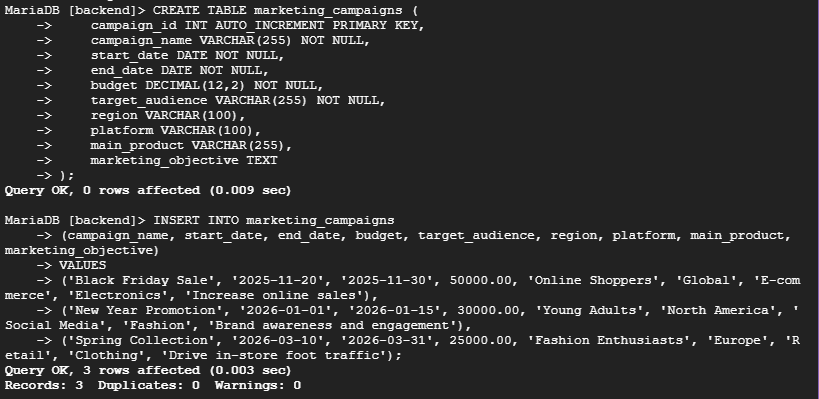

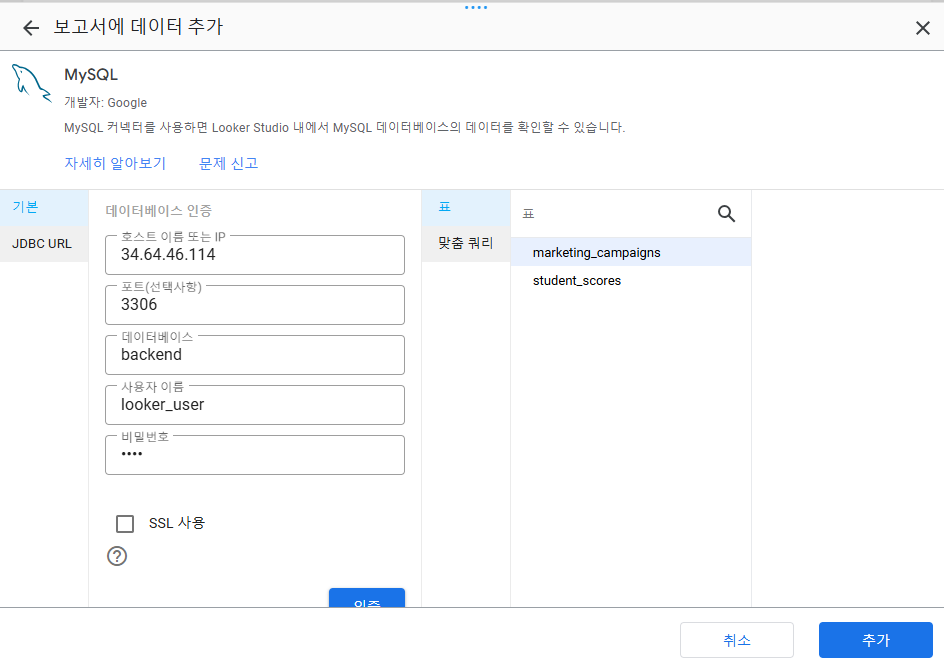

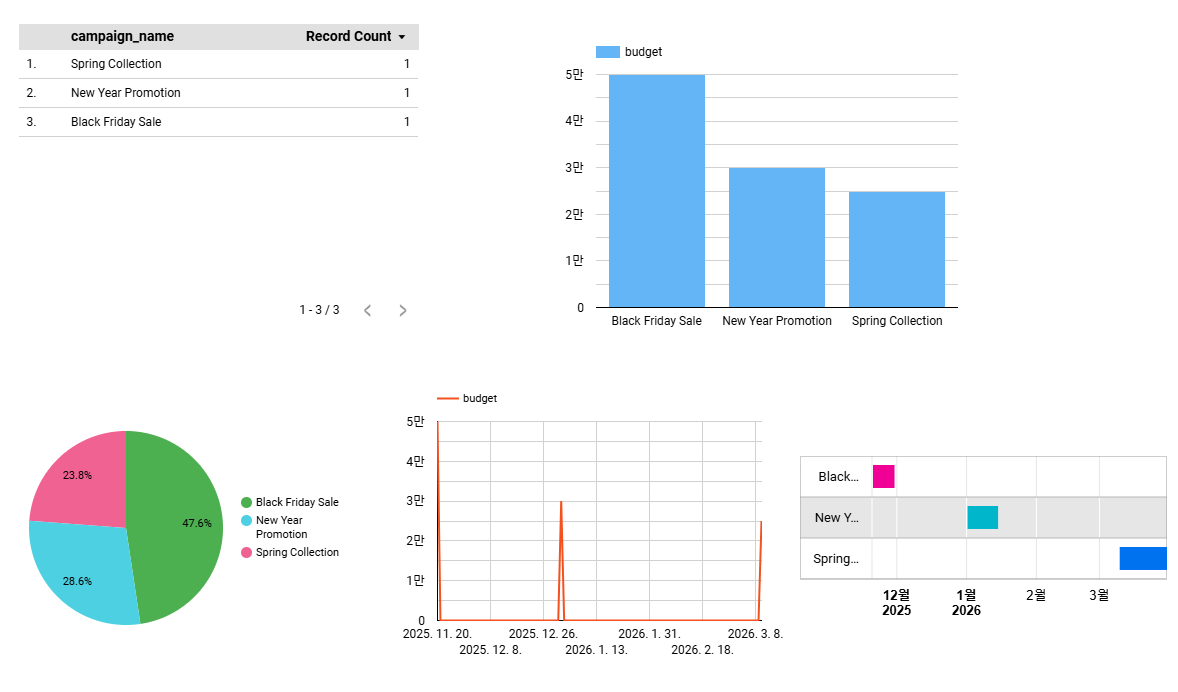



---



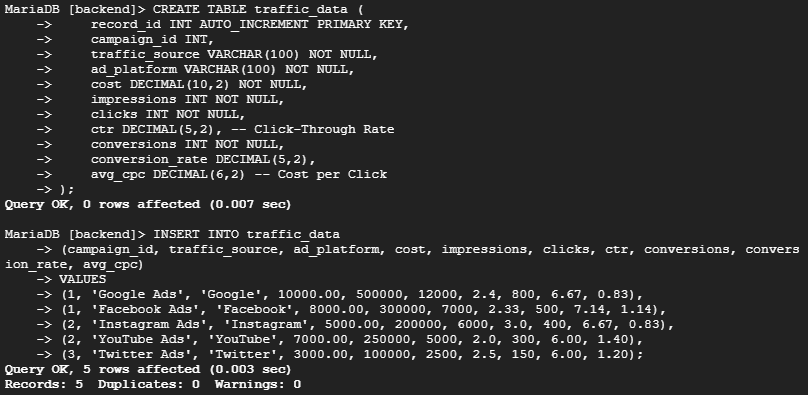

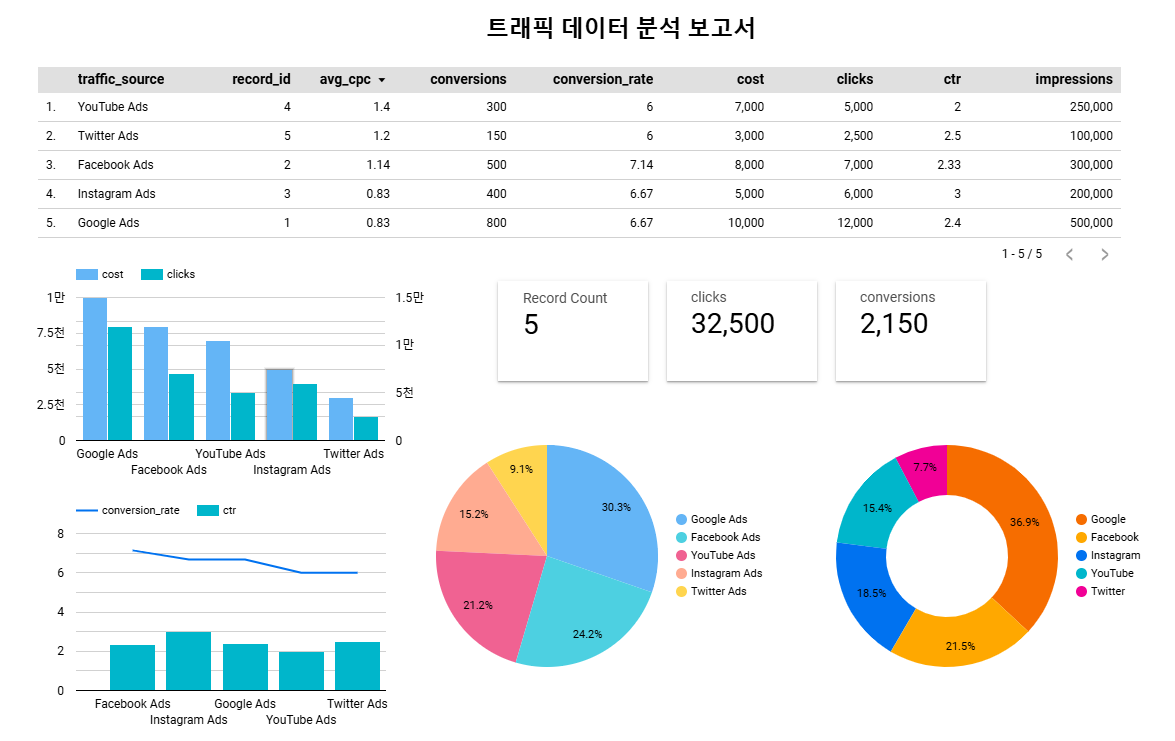



---



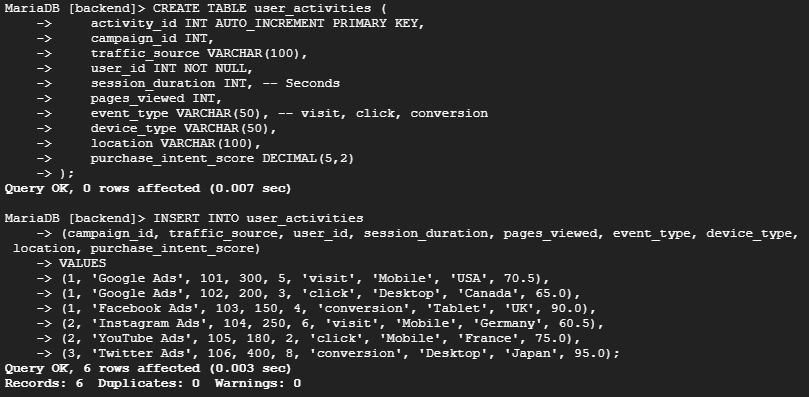

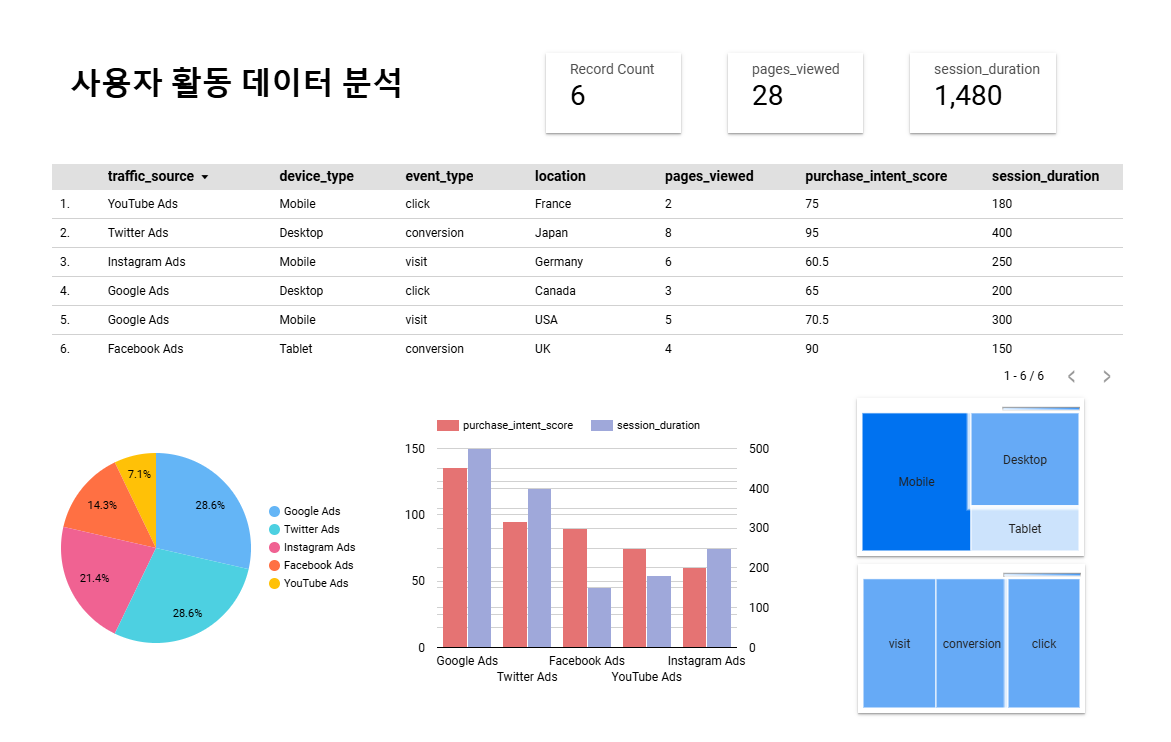

공유 링크 https://lookerstudio.google.com/s/hdnAKakZcLI



---



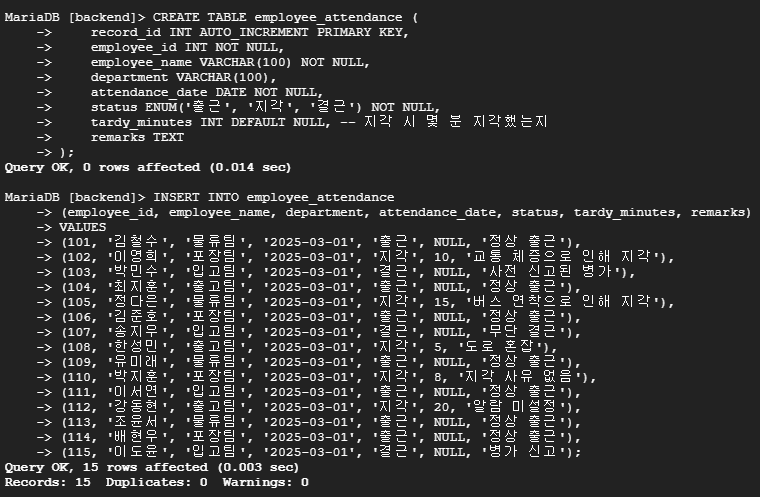

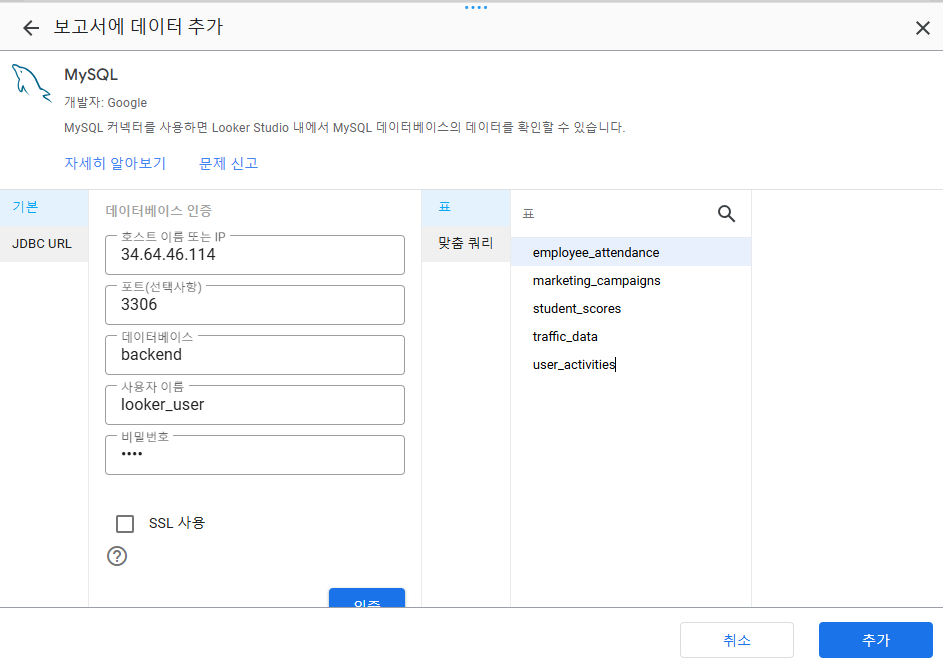

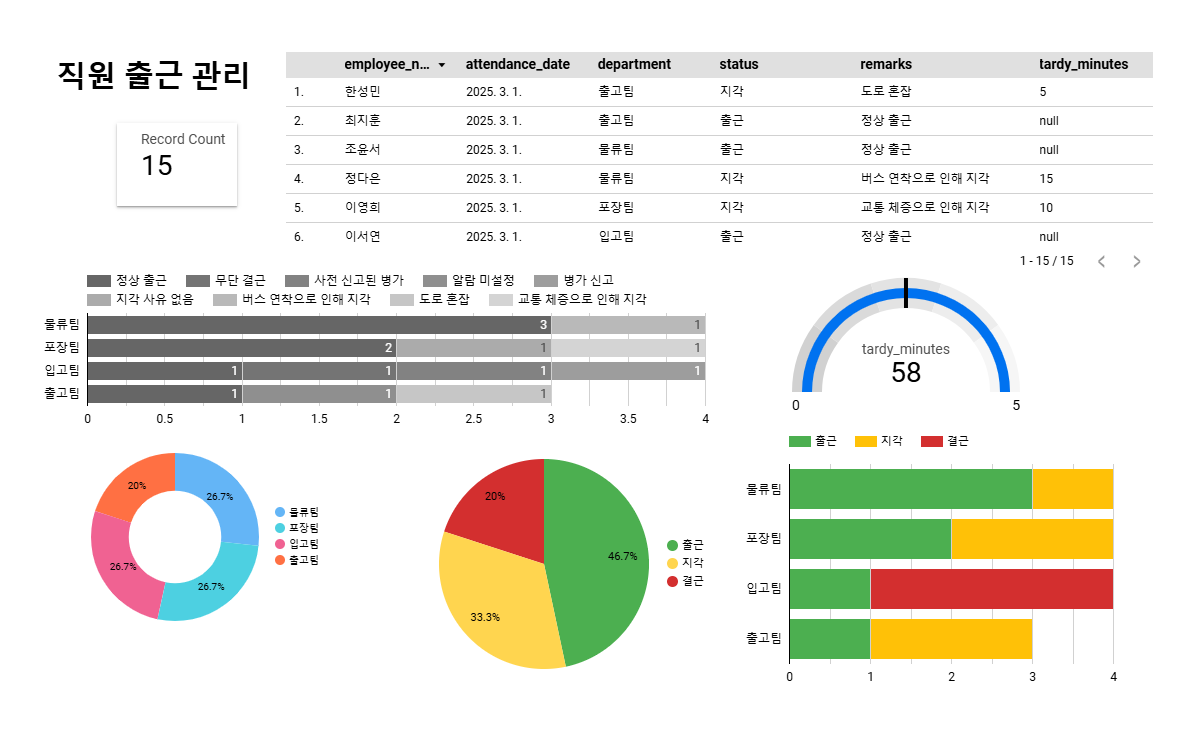



---



##**flask & chart.js - Web**

디렉토리 구조

```arduino
site2/
│
├── app.py
├── textData.py
└── templates/
    └── index.html
```


app.py

In [ ]:
from flask import Flask, render_template, jsonify
from textData import text_data

app = Flask(__name__)

@app.route('/')
def index():
    # 텍스트 데이터와 그래프 데이터를 전달
    return render_template('index.html', text_data=text_data)

@app.route('/data')
def get_data():
    # 그래프 데이터를 JSON으로 반환
    return jsonify(text_data)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001, debug=True)

textData.py

In [ ]:
text_data = {
    "profitability": {
        "data": {
            "periods": ["2023-01", "2023-02", "2023-03", "2023-04", "2023-05", "2023-06", "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12"],
            "operating_profit_margin": [-5, -10, 3, 4, -7, -8, 2, 0, -5, -15, -10, -12],
            "net_profit_margin": [-10, -15, 2, 3, -12, -13, 1, -1, -10, -18, -15, -17]
        },
        "description": {
            "operating_profit_margin": (
                "영업이익률: 전체적으로 영업이익률은 2023년 초반에는 마이너스에서 출발했으나, "
                "일부 달에서는 소폭의 양호한 실적을 보였습니다. 하지만 연말로 갈수록 다시 하락세를 "
                "보여 지속적인 개선이 필요합니다."
            ),
            "net_profit_margin": (
                "순이익률: 순이익률은 전반적으로 낮은 상태를 유지하고 있으며, 특히 연말로 갈수록 "
                "부정적인 수치를 기록하고 있습니다. 회사의 순이익을 증대시키기 위한 대책이 필요합니다."
            )
        }
    },
    "solvency": {
        "data": {
            "debt_to_equity_ratio": [55, 60, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56],
            "current_ratio": [180, 175, 170, 168, 166, 165, 160, 158, 157, 155, 152, 150]
        },
        "description": {
            "debt_to_equity_ratio": (
                "부채비율: 부채비율은 연중 안정적인 수준을 유지하고 있으며, 60%대에서 점차 감소하는 "
                "추세를 보이고 있습니다."
            ),
            "current_ratio": (
                "유동비율: 유동비율은 안정적으로 150%에서 180% 사이를 유지하며, 회사의 단기 채무 상환 능력이 "
                "우수함을 나타냅니다."
            )
        }
    },
    "efficiency": {
        "data": {
            "asset_turnover": [0.5, 0.52, 0.53, 0.55, 0.57, 0.58, 0.6, 0.62, 0.63, 0.64, 0.65, 0.66],
            "roe": [-5, -6, 0, 1, -2, -3, 2, 1, -4, -5, -6, -7]
        },
        "description": {
            "asset_turnover": (
                "자산 회전율: 자산 회전율은 점차 증가하는 추세를 보이며, 자산이 매출을 창출하는 데 점차 "
                "효율적으로 사용되고 있음을 시사합니다."
            ),
            "roe": (
                "ROE (자본 대비 순이익률): ROE는 일부 기간 동안 양호한 실적을 보였으나, 연말로 갈수록 "
                "부정적인 수치를 보였습니다. 자본의 효과적인 활용을 위해 개선이 필요합니다."
            )
        }
    }
}

/templates/index.html

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Financial Analysis Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 0;
            background-color: #f4f4f4;
            color: #333;
        }

        h1 {
            text-align: center;
            padding: 20px;
            background-color: #333;
            color: white;
        }

        section {
            margin: 20px;
            padding: 20px;
            background-color: white;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
        }

        h2 {
            color: #333;
            margin-bottom: 10px;
        }

        .analysis-text {
            font-size: 16px;
            line-height: 1.6;
            margin-bottom: 20px;
            padding: 15px;
            border-left: 5px solid #333;
            background-color: #f9f9f9;
            border-radius: 5px;
            box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
        }

        canvas {
            margin: 20px 0;
        }

        .chart-container {
            display: flex;
            justify-content: space-around;
            flex-wrap: wrap;
        }

        .chart-box {
            width: 45%;
            margin-bottom: 20px;
        }

        footer {
            text-align: center;
            padding: 10px;
            background-color: #333;
            color: white;
            position: fixed;
            width: 100%;
            bottom: 0;
        }
    </style>
</head>
<body>
    <h1>Financial Analysis Dashboard</h1>

    <section>
        <h2>1. 수익성 분석</h2>
        <div class="analysis-text">{{ text_data.profitability.description.operating_profit_margin }}</div>
        <div class="analysis-text">{{ text_data.profitability.description.net_profit_margin }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="profitabilityChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="profitabilityPieChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <section>
        <h2>2. 재무 건전성 분석</h2>
        <div class="analysis-text">{{ text_data.solvency.description.debt_to_equity_ratio }}</div>
        <div class="analysis-text">{{ text_data.solvency.description.current_ratio }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="solvencyChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="solvencyBarChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <section>
        <h2>3. 운영 효율성 분석</h2>
        <div class="analysis-text">{{ text_data.efficiency.description.asset_turnover }}</div>
        <div class="analysis-text">{{ text_data.efficiency.description.roe }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="efficiencyChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="efficiencyPieChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <footer>
        © 2024 Gabkeun, Choi., Ph.D
    </footer>

    <script>
        const textData = {{ text_data | tojson }};
        const profitabilityCtx = document.getElementById('profitabilityChart').getContext('2d');

        new Chart(profitabilityCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '영업이익률 (%)',
                        data: textData.profitability.data.operating_profit_margin,
                        borderColor: 'rgba(75, 192, 192, 1)',
                        fill: false
                    },
                    {
                        label: '순이익률 (%)',
                        data: textData.profitability.data.net_profit_margin,
                        borderColor: 'rgba(255, 99, 132, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const profitabilityPieCtx = document.getElementById('profitabilityPieChart').getContext('2d');
        new Chart(profitabilityPieCtx, {
            type: 'pie',
            data: {
                labels: ['영업이익률', '순이익률'],
                datasets: [{
                    label: '수익성',
                    data: [
                        textData.profitability.data.operating_profit_margin.reduce((a, b) => a + b, 0),
                        textData.profitability.data.net_profit_margin.reduce((a, b) => a + b, 0)
                    ],
                    backgroundColor: [
                        'rgba(75, 192, 192, 0.5)',
                        'rgba(255, 99, 132, 0.5)'
                    ],
                    borderColor: [
                        'rgba(75, 192, 192, 1)',
                        'rgba(255, 99, 132, 1)'
                    ],
                    borderWidth: 1
                }]
            },
            options: {
                responsive: true
            }
        });

        const solvencyCtx = document.getElementById('solvencyChart').getContext('2d');
        new Chart(solvencyCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        borderColor: 'rgba(54, 162, 235, 1)',
                        fill: false
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        borderColor: 'rgba(153, 102, 255, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const solvencyBarCtx = document.getElementById('solvencyBarChart').getContext('2d');
        new Chart(solvencyBarCtx, {
            type: 'bar',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        backgroundColor: 'rgba(54, 162, 235, 0.5)',
                        borderColor: 'rgba(54, 162, 235, 1)',
                        borderWidth: 1
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        backgroundColor: 'rgba(153, 102, 255, 0.5)',
                        borderColor: 'rgba(153, 102, 255, 1)',
                        borderWidth: 1
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const efficiencyCtx = document.getElementById('efficiencyChart').getContext('2d');
        new Chart(efficiencyCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '자산 회전율',
                        data: textData.efficiency.data.asset_turnover,
                        borderColor: 'rgba(255, 159, 64, 1)',
                        fill: false
                    },
                    {
                        label: 'ROE (%)',
                        data: textData.efficiency.data.roe,
                        borderColor: 'rgba(75, 192, 192, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const efficiencyPieCtx = document.getElementById('efficiencyPieChart').getContext('2d');
        new Chart(efficiencyPieCtx, {
            type: 'pie',
            data: {
                labels: ['자산 회전율', 'ROE (%)'],
                datasets: [{
                    label: '효율성',
                    data: [
                        textData.efficiency.data.asset_turnover.reduce((a, b) => a + b, 0),
                        textData.efficiency.data.roe.reduce((a, b) => a + b, 0)
                    ],
                    backgroundColor: [
                        'rgba(255, 159, 64, 0.5)',
                        'rgba(75, 192, 192, 0.5)'
                    ],
                    borderColor: [
                        'rgba(255, 159, 64, 1)',
                        'rgba(75, 192, 192, 1)'
                    ],
                    borderWidth: 1
                }]
            },
            options: {
                responsive: true
            }
        });
    </script>
</body>
</html>

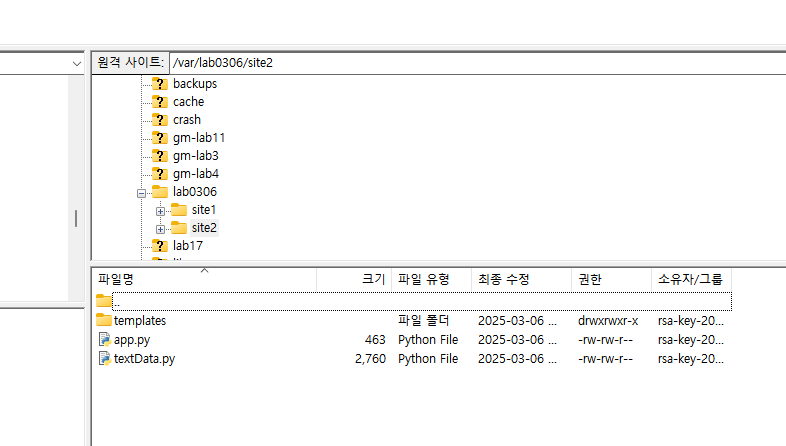

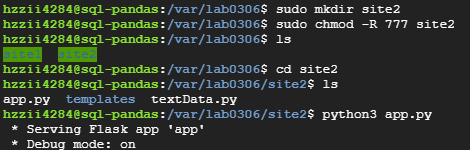

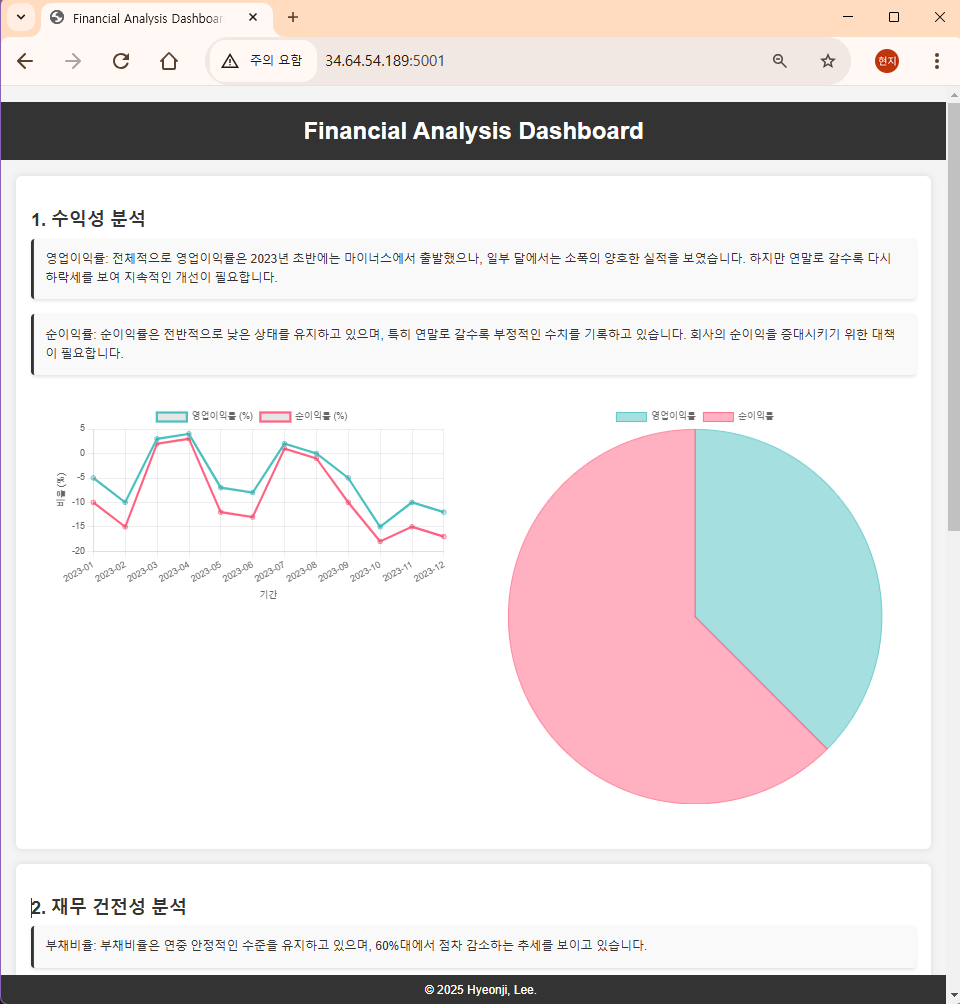  
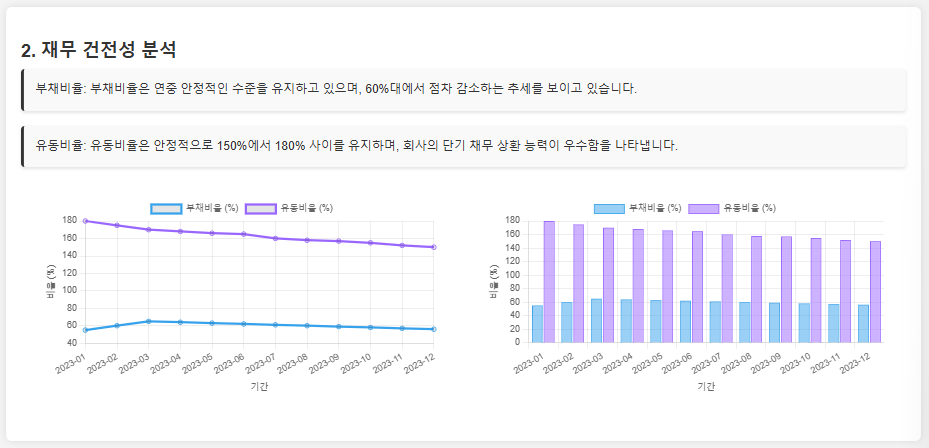  
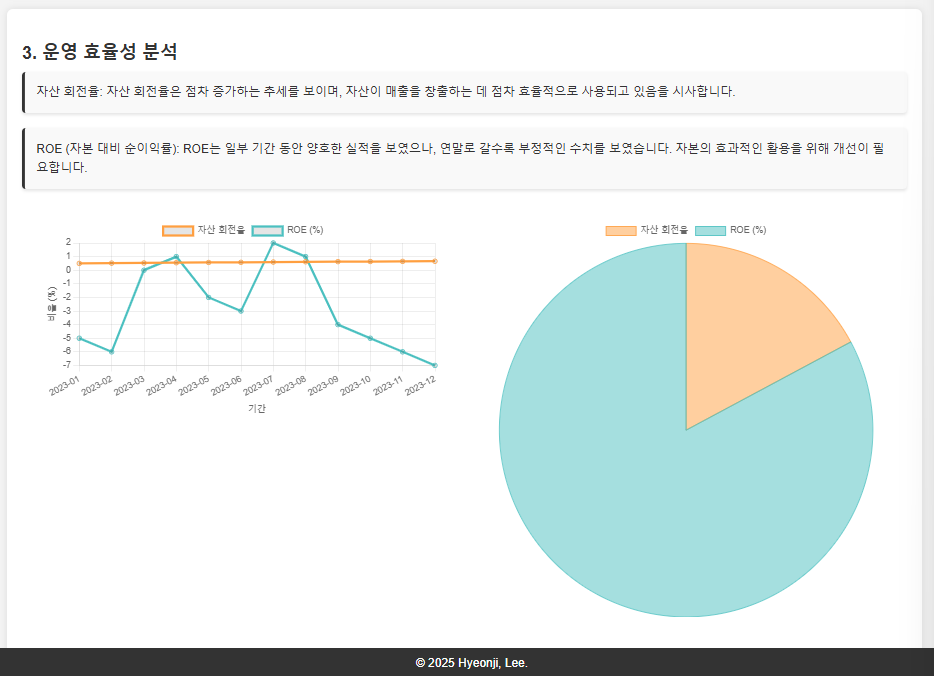



---

##**연습문제**

문제 1 : 다음은 공시자료를 통한 삼성전자의 2023년도 경영분석과 투자조언 내용입니다. 아래의 내용을 위 코드에 통합하여 웹서비스 가 가능하도록 하고 서비스 운영상황을 보이세요.

textData.py

In [ ]:
text_data = {
    "profitability": {
        "data": {
            "periods": [
                "2023-01", "2023-02", "2023-03", "2023-04", "2023-05", "2023-06",
                "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12"
            ],
            "operating_profit_margin": [7.8, 8.0, 7.6, 7.4, 7.2, 7.5, 7.7, 8.0, 8.1, 7.9, 7.8, 7.94],
            "net_profit_margin": [9.5, 9.7, 9.3, 9.1, 8.9, 9.4, 9.6, 9.8, 9.7, 9.5, 9.4, 9.88]
        },
        "description": {
            "operating_profit_margin": (
                "영업이익률: 삼성전자의 영업이익률은 2023년 동안 비교적 안정적으로 유지되었으나, 글로벌 경제 불확실성과 "
                "원자재 비용 상승으로 인해 하락 압력을 받았습니다. "
                "투자 조언: 영업이익률의 변동성을 주의 깊게 모니터링하고, 장기적인 수익성 향상 여부를 주시할 필요가 있습니다."
            ),
            "net_profit_margin": (
                "순이익률: 2023년 동안 순이익률은 안정적인 수준을 유지하였으며, 이는 회사의 견고한 재무 구조를 반영합니다. "
                "투자 조언: 안정적인 순이익률은 장기 투자 관점에서 긍정적인 신호로 볼 수 있으며, 포트폴리오 다각화에 고려될 수 있습니다."
            )
        }
    },
    "solvency": {
        "data": {
            "periods": [
                "2023-01", "2023-02", "2023-03", "2023-04", "2023-05", "2023-06",
                "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12"
            ],
            "debt_to_equity_ratio": [24.3, 24.2, 24.1, 24.0, 23.9, 23.8, 23.7, 23.6, 23.5, 23.4, 23.5, 24],
            "current_ratio": [1.88, 1.89, 1.87, 1.86, 1.85, 1.88, 1.89, 1.9, 1.88, 1.87, 1.88, 1.9]
        },
        "description": {
            "debt_to_equity_ratio": (
                "부채비율: 2023년 동안 삼성전자의 부채비율은 점진적으로 감소하여 재정 건전성이 향상되었습니다. "
                "투자 조언: 부채비율의 안정적인 감소는 장기적인 재무 안정성을 의미하며, 이는 투자자에게 긍정적인 신호로 작용할 수 있습니다."
            ),
            "current_ratio": (
                "유동비율: 2023년 유동비율은 안정적인 범위에서 유지되었으며, 이는 회사의 단기 채무 상환 능력을 나타냅니다. "
                "투자 조언: 유동비율이 안정적이라는 것은 회사가 단기적인 재정 압박에 대응할 수 있음을 의미하며, 투자 안정성의 중요한 지표입니다."
            )
        }
    }
}

templates/index.html

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Samsung Financial Analysis Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 0;
            background-color: #f4f4f4;
            color: #333;
        }

        h1 {
            text-align: center;
            padding: 20px;
            background-color: #333;
            color: white;
        }

        section {
            margin: 20px;
            padding: 20px;
            background-color: white;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
        }

        h2 {
            color: #333;
            margin-bottom: 10px;
        }

        .analysis-text {
            font-size: 16px;
            line-height: 1.6;
            margin-bottom: 20px;
            padding: 15px;
            border-left: 5px solid #333;
            background-color: #f9f9f9;
            border-radius: 5px;
            box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
        }

        canvas {
            margin: 20px 0;
        }

        .chart-container {
            display: flex;
            justify-content: space-around;
            flex-wrap: wrap;
        }

        .chart-box {
            width: 45%;
            margin-bottom: 20px;
        }

        footer {
            text-align: center;
            padding: 10px;
            background-color: #333;
            color: white;
            position: fixed;
            width: 100%;
            bottom: 0;
        }
    </style>
</head>
<body>
    <h1>Samsung Financial Analysis Dashboard</h1>

    <section>
        <h2>1. 수익성 분석</h2>
        <div class="analysis-text">{{ text_data.profitability.description.operating_profit_margin }}</div>
        <div class="analysis-text">{{ text_data.profitability.description.net_profit_margin }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="profitabilityChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="profitabilityPieChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <section>
        <h2>2. 재무 건전성 분석</h2>
        <div class="analysis-text">{{ text_data.solvency.description.debt_to_equity_ratio }}</div>
        <div class="analysis-text">{{ text_data.solvency.description.current_ratio }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="solvencyChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="solvencyBarChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <footer>
        © 2025 Hyeonji, Lee.
    </footer>

    <script>
        const textData = {{ text_data | tojson }};
        const profitabilityCtx = document.getElementById('profitabilityChart').getContext('2d');

        new Chart(profitabilityCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '영업이익률 (%)',
                        data: textData.profitability.data.operating_profit_margin,
                        borderColor: 'rgba(75, 192, 192, 1)',
                        fill: false
                    },
                    {
                        label: '순이익률 (%)',
                        data: textData.profitability.data.net_profit_margin,
                        borderColor: 'rgba(255, 99, 132, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const profitabilityPieCtx = document.getElementById('profitabilityPieChart').getContext('2d');
        new Chart(profitabilityPieCtx, {
            type: 'pie',
            data: {
                labels: ['영업이익률', '순이익률'],
                datasets: [{
                    label: '수익성',
                    data: [
                        textData.profitability.data.operating_profit_margin.reduce((a, b) => a + b, 0),
                        textData.profitability.data.net_profit_margin.reduce((a, b) => a + b, 0)
                    ],
                    backgroundColor: [
                        'rgba(75, 192, 192, 0.5)',
                        'rgba(255, 99, 132, 0.5)'
                    ],
                    borderColor: [
                        'rgba(75, 192, 192, 1)',
                        'rgba(255, 99, 132, 1)'
                    ],
                    borderWidth: 1
                }]
            },
            options: {
                responsive: true
            }
        });

        const solvencyCtx = document.getElementById('solvencyChart').getContext('2d');
        new Chart(solvencyCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        borderColor: 'rgba(54, 162, 235, 1)',
                        fill: false
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        borderColor: 'rgba(153, 102, 255, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const solvencyBarCtx = document.getElementById('solvencyBarChart').getContext('2d');
        new Chart(solvencyBarCtx, {
            type: 'bar',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        backgroundColor: 'rgba(54, 162, 235, 0.5)',
                        borderColor: 'rgba(54, 162, 235, 1)',
                        borderWidth: 1
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        backgroundColor: 'rgba(153, 102, 255, 0.5)',
                        borderColor: 'rgba(153, 102, 255, 1)',
                        borderWidth: 1
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

    </script>
</body>
</html>

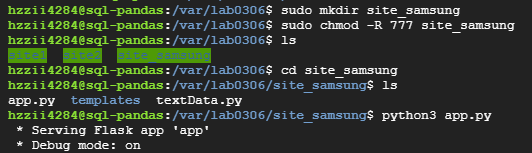

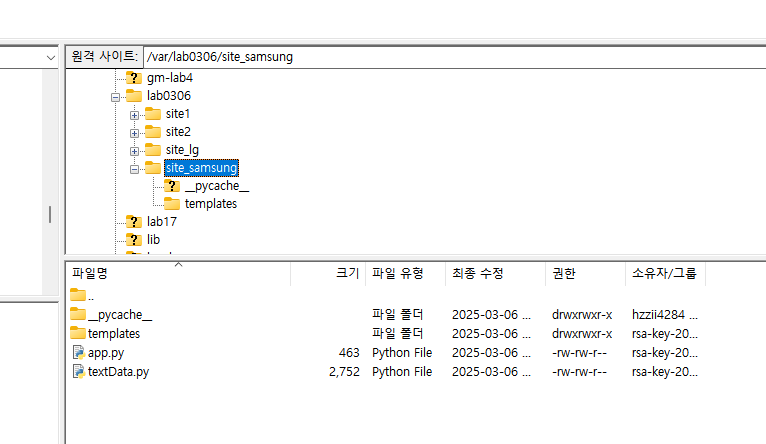

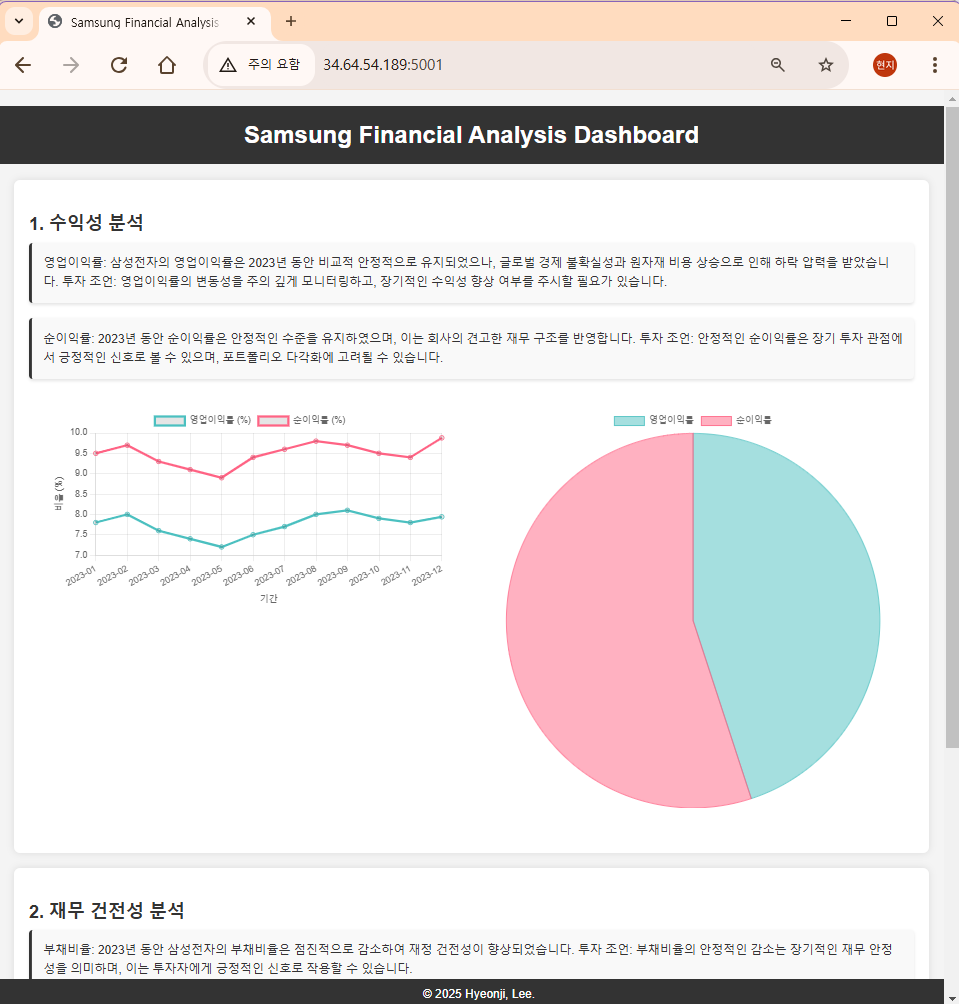  
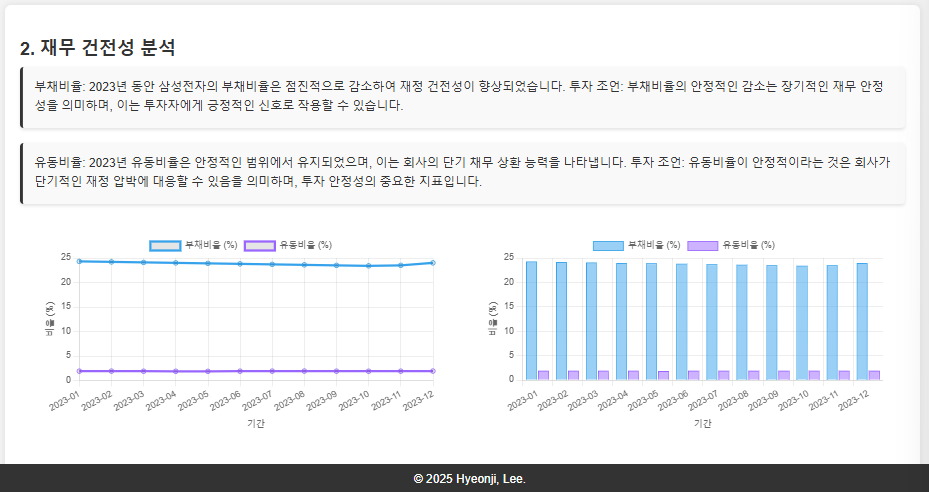

문제 2 : 다음은 공시자료를 통한 엘지전자의 2023년도 경영분석과 투자조언 내용입니다. 아래의 내용을 위 코드에 통합하여 웹서비스 가 가능하도록 하고 서비스 운영상황을 보이세요.

textData.py

In [ ]:
text_data = {
    "profitability": {
        "data": {
            "periods": [
                "2023-01", "2023-02", "2023-03", "2023-04", "2023-05", "2023-06",
                "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12"
            ],
            "operating_profit_margin": [7.5, 7.6, 7.7, 7.8, 7.6, 7.7, 7.8, 8.0, 8.1, 8.0, 7.9, 8.1],
            "net_profit_margin": [9.4, 9.5, 9.6, 9.7, 9.5, 9.6, 9.7, 9.8, 9.9, 9.8, 9.7, 9.9]
        },
        "description": {
            "operating_profit_margin": (
                "영업이익률: LG전자의 영업이익률은 2023년 동안 비교적 안정적인 수준을 유지하였습니다. "
                "이는 효율적인 비용 관리와 고수익 제품에 대한 집중이 반영된 결과입니다. "
                "투자 조언: 영업이익률이 안정적으로 유지되고 있다는 점은 장기적인 수익성의 긍정적인 신호로, "
                "안정적인 수익을 기대하는 투자자들에게 적합한 투자 기회로 판단될 수 있습니다."
            ),
            "net_profit_margin": (
                "순이익률: LG전자의 2023년 순이익률은 연중 꾸준히 9.4%에서 9.9% 사이에서 안정적인 성과를 보여주었습니다. "
                "이는 다양한 사업 부문에서의 견고한 수익 창출 능력을 의미합니다. "
                "투자 조언: 안정적인 순이익률은 LG전자의 재무 건전성을 나타내며, 포트폴리오 다각화를 원하는 투자자에게 "
                "안정적인 투자 기회를 제공합니다."
            )
        }
    },
    "solvency": {
        "data": {
            "periods": [
                "2023-01", "2023-02", "2023-03", "2023-04", "2023-05", "2023-06",
                "2023-07", "2023-08", "2023-09", "2023-10", "2023-11", "2023-12"
            ],
            "debt_to_equity_ratio": [24.5, 24.4, 24.3, 24.2, 24.1, 24.0, 23.9, 23.8, 23.7, 23.6, 23.5, 23.4],
            "current_ratio": [1.85, 1.86, 1.87, 1.88, 1.87, 1.88, 1.89, 1.9, 1.88, 1.87, 1.88, 1.9]
        },
        "description": {
            "debt_to_equity_ratio": (
                "부채비율: 2023년 동안 LG전자의 부채비율은 점진적으로 감소하였으며, 이는 재무 건전성이 개선되고 있음을 나타냅니다. "
                "투자 조언: 부채비율의 하락은 회사의 재정적 위험이 감소하고 있음을 시사하므로, 장기적인 안정성을 중시하는 "
                "투자자에게 긍정적인 신호로 작용할 수 있습니다."
            ),
            "current_ratio": (
                "유동비율: LG전자의 유동비율은 2023년 동안 1.85에서 1.9 사이에서 안정적으로 유지되었습니다. 이는 회사가 단기적인 "
                "재정적 압박에 잘 대응할 수 있음을 보여줍니다. "
                "투자 조언: 유동비율이 안정적으로 유지된다는 점은 재정적 안정성의 중요한 지표로, 안정적인 수익을 추구하는 "
                "투자자에게 매력적인 투자 기회를 제공합니다."
            )
        }
    }
}

templates/index.html

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>LG Financial Analysis Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 0;
            background-color: #f4f4f4;
            color: #333;
        }

        h1 {
            text-align: center;
            padding: 20px;
            background-color: #333;
            color: white;
        }

        section {
            margin: 20px;
            padding: 20px;
            background-color: white;
            border-radius: 8px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
        }

        h2 {
            color: #333;
            margin-bottom: 10px;
        }

        .analysis-text {
            font-size: 16px;
            line-height: 1.6;
            margin-bottom: 20px;
            padding: 15px;
            border-left: 5px solid #333;
            background-color: #f9f9f9;
            border-radius: 5px;
            box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
        }

        canvas {
            margin: 20px 0;
        }

        .chart-container {
            display: flex;
            justify-content: space-around;
            flex-wrap: wrap;
        }

        .chart-box {
            width: 45%;
            margin-bottom: 20px;
        }

        footer {
            text-align: center;
            padding: 10px;
            background-color: #333;
            color: white;
            position: fixed;
            width: 100%;
            bottom: 0;
        }
    </style>
</head>
<body>
    <h1>LG Financial Analysis Dashboard</h1>

    <section>
        <h2>1. 수익성 분석</h2>
        <div class="analysis-text">{{ text_data.profitability.description.operating_profit_margin }}</div>
        <div class="analysis-text">{{ text_data.profitability.description.net_profit_margin }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="profitabilityChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="profitabilityPieChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <section>
        <h2>2. 재무 건전성 분석</h2>
        <div class="analysis-text">{{ text_data.solvency.description.debt_to_equity_ratio }}</div>
        <div class="analysis-text">{{ text_data.solvency.description.current_ratio }}</div>
        <div class="chart-container">
            <div class="chart-box">
                <canvas id="solvencyChart" width="400" height="200"></canvas>
            </div>
            <div class="chart-box">
                <canvas id="solvencyBarChart" width="400" height="200"></canvas>
            </div>
        </div>
    </section>

    <footer>
        © 2025 Hyeonji, Lee.
    </footer>

    <script>
        const textData = {{ text_data | tojson }};
        const profitabilityCtx = document.getElementById('profitabilityChart').getContext('2d');

        new Chart(profitabilityCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '영업이익률 (%)',
                        data: textData.profitability.data.operating_profit_margin,
                        borderColor: 'rgba(75, 192, 192, 1)',
                        fill: false
                    },
                    {
                        label: '순이익률 (%)',
                        data: textData.profitability.data.net_profit_margin,
                        borderColor: 'rgba(255, 99, 132, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const profitabilityPieCtx = document.getElementById('profitabilityPieChart').getContext('2d');
        new Chart(profitabilityPieCtx, {
            type: 'pie',
            data: {
                labels: ['영업이익률', '순이익률'],
                datasets: [{
                    label: '수익성',
                    data: [
                        textData.profitability.data.operating_profit_margin.reduce((a, b) => a + b, 0),
                        textData.profitability.data.net_profit_margin.reduce((a, b) => a + b, 0)
                    ],
                    backgroundColor: [
                        'rgba(75, 192, 192, 0.5)',
                        'rgba(255, 99, 132, 0.5)'
                    ],
                    borderColor: [
                        'rgba(75, 192, 192, 1)',
                        'rgba(255, 99, 132, 1)'
                    ],
                    borderWidth: 1
                }]
            },
            options: {
                responsive: true
            }
        });

        const solvencyCtx = document.getElementById('solvencyChart').getContext('2d');
        new Chart(solvencyCtx, {
            type: 'line',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        borderColor: 'rgba(54, 162, 235, 1)',
                        fill: false
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        borderColor: 'rgba(153, 102, 255, 1)',
                        fill: false
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

        const solvencyBarCtx = document.getElementById('solvencyBarChart').getContext('2d');
        new Chart(solvencyBarCtx, {
            type: 'bar',
            data: {
                labels: textData.profitability.data.periods,
                datasets: [
                    {
                        label: '부채비율 (%)',
                        data: textData.solvency.data.debt_to_equity_ratio,
                        backgroundColor: 'rgba(54, 162, 235, 0.5)',
                        borderColor: 'rgba(54, 162, 235, 1)',
                        borderWidth: 1
                    },
                    {
                        label: '유동비율 (%)',
                        data: textData.solvency.data.current_ratio,
                        backgroundColor: 'rgba(153, 102, 255, 0.5)',
                        borderColor: 'rgba(153, 102, 255, 1)',
                        borderWidth: 1
                    }
                ]
            },
            options: {
                responsive: true,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: '기간'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: '비율 (%)'
                        }
                    }
                }
            }
        });

    </script>
</body>
</html>

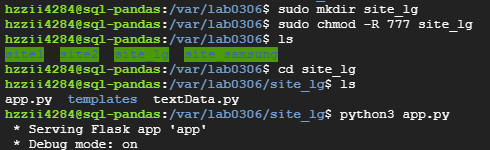

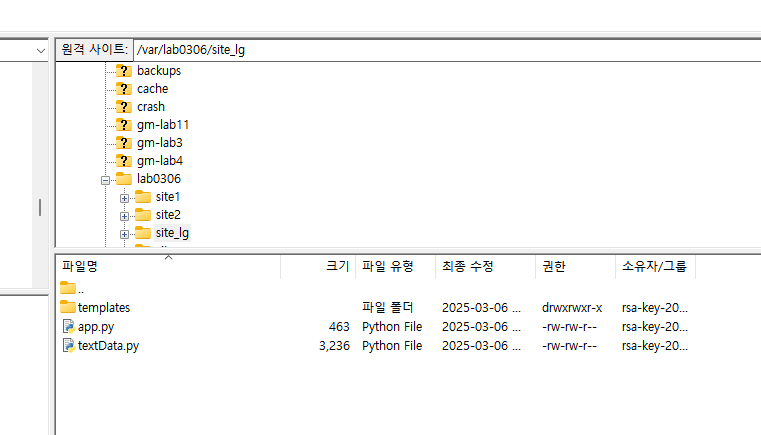

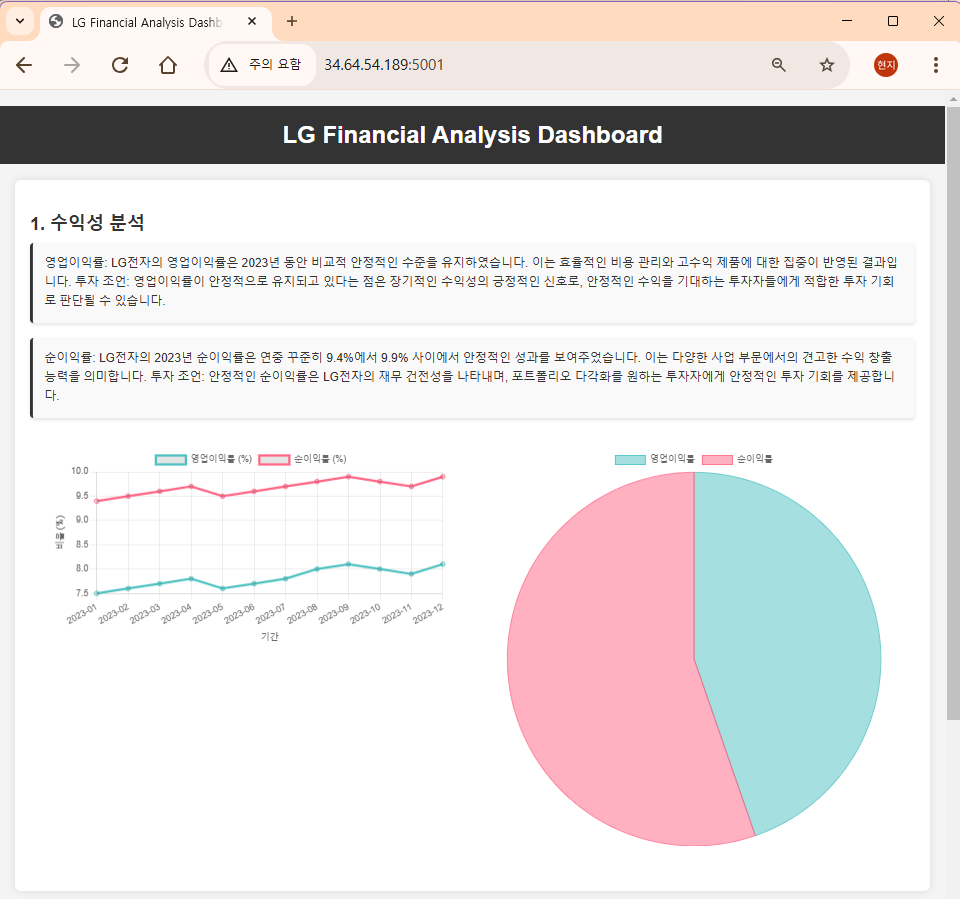  
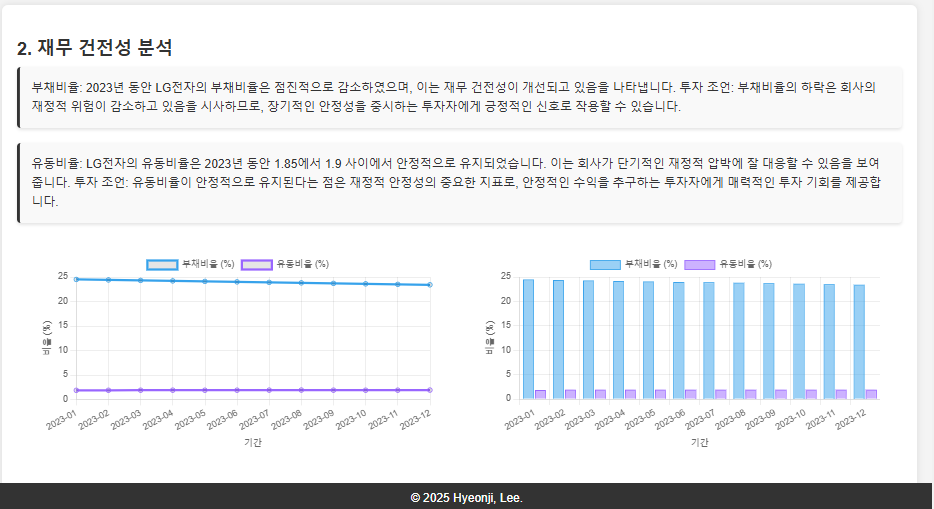